In [3]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [font for font in 'Liberation Sans, DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif'.split(', ')] 
plt.rcParams['mathtext.fontset'] = 'stixsans'

plt.rcParams['axes.linewidth'] = 1
plt.rcParams['grid.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 6

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FormatStrFormatter

In [4]:
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'

entropy_all_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDebrisflag_df.tsv')

entropy_all = pd.read_csv(entropy_all_file, sep=',', index_col=0)
entropy_all['atac_bc'] = entropy_all.index.str.split('-').str[0]

entropy_all.shape

(33287, 8)

In [5]:
entropy_w_DNAdebrisflag_file = os.path.join(entropy_dir, 'entropy_filtered_bc_w_Debrisflag_df.tsv')

entropy_w_DNAdebrisflag_df = pd.read_csv(entropy_w_DNAdebrisflag_file, sep=',', index_col=0)
entropy_w_DNAdebrisflag_df['atac_bc'] = entropy_w_DNAdebrisflag_df.index.str.split('-').str[0]

entropy_w_DNAdebrisflag_df.shape

(2125, 8)

In [6]:
final_bc_file = os.path.join(entropy_dir, 'entropy_filtered_bc_df.tsv')

entropy_df = pd.read_csv(final_bc_file, sep=',', index_col=0)
entropy_df['atac_bc'] = entropy_df.index.str.split('-').str[0]

entropy_df.shape

(2101, 8)

In [7]:
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG
GGAGGCTTCATGGATA-1,0.969950,0.401102,2468,0.077603,0.925332,0.601704,NO,GGAGGCTTCATGGATA


# Prepare for illustratrion figure

In [10]:
# Preparation of scatter plot data
frag_file = os.path.join(entropy_dir, 'fragments.tsv')

frag_df = pd.read_csv(frag_file, sep='\t', header=None, names=['chr', 'start', 'end', 'atac_barcodes', 'support'])
frag_df['atac_bc'] = frag_df['atac_barcodes'].str.split('-').str[0]

total_fragments = frag_df.groupby('atac_barcodes').size().reset_index(name='total_fragments')
total_fragments.set_index('atac_barcodes', inplace=True)

In [11]:
for df in [entropy_all, entropy_w_DNAdebrisflag_df, entropy_df]:
    df['total_fragments'] = df.index.map(total_fragments['total_fragments'])
    
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc,total_fragments
CGTGTTTCAAACCTAG-1,0.998157,1.989804,26417,1.111023,0.329222,0.525430,NO,CGTGTTTCAAACCTAG,398925
GGAGGCTTCATGGATA-1,0.969950,0.401102,2468,0.077603,0.925332,0.601704,NO,GGAGGCTTCATGGATA,52518


In [12]:
for df in [entropy_all, entropy_w_DNAdebrisflag_df, entropy_df]:
    df['log_total_fragments'] = np.log1p(df['total_fragments'])
    df['log_entropy'] = np.log2(df['Entropy'])

# Figure

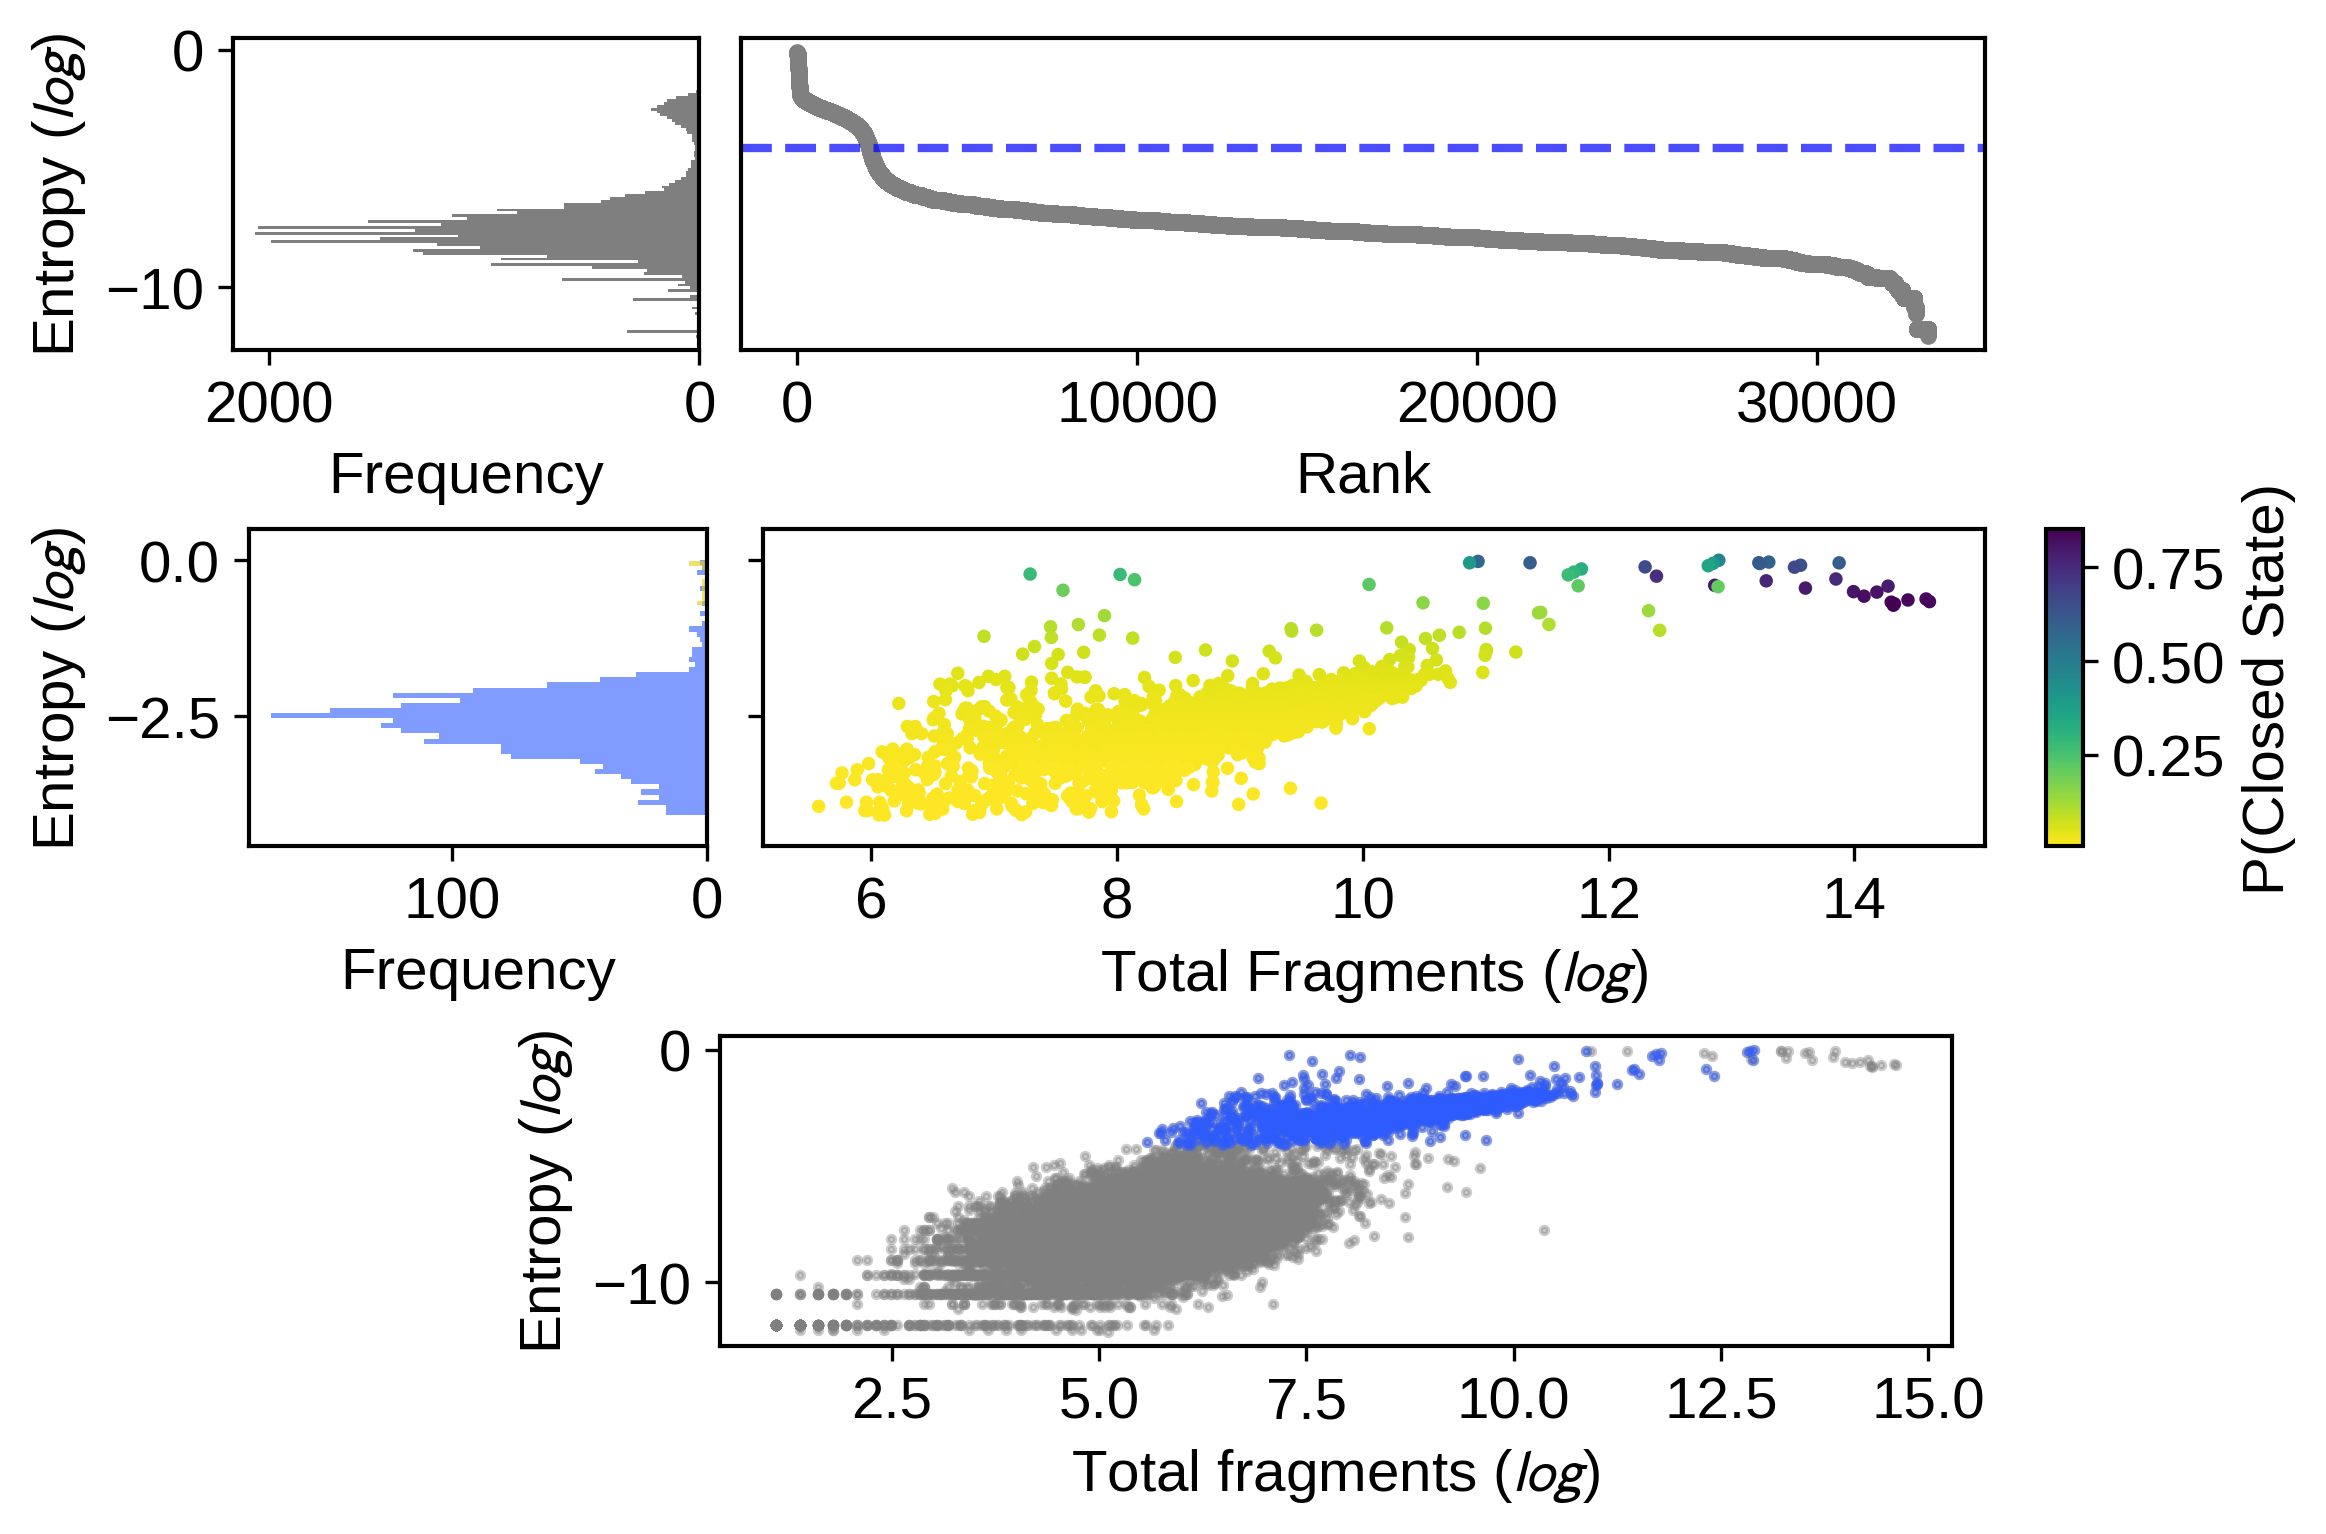

In [13]:
fig = plt.figure(layout="constrained", figsize=(6.6, 5))

# Create a top-level GridSpec with 3 rows
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1])

# --- Row 1 ---
gs0 = gs[0].subgridspec(1, 2, width_ratios=[3, 8])
ax1 = fig.add_subplot(gs0[0, 0])
ax2 = fig.add_subplot(gs0[0, 1])

# --- Row 2 ---
gs1 = gs[1].subgridspec(1, 2, width_ratios=[3, 8])
ax3 = fig.add_subplot(gs1[0, 0])
ax4 = fig.add_subplot(gs1[0, 1])

# --- Row 3 ---
# ax5 = fig.add_subplot(gs[2, 0])
gs2 = gs[2].subgridspec(1, 2, width_ratios=[3, 8])
ax5 = fig.add_subplot(gs2[0, 0])
ax6 = fig.add_subplot(gs2[0, 1])


entropy_min, entropy_max = entropy_all['log_entropy'].min(), entropy_all['log_entropy'].max()

# ax1
s1 = ax1.hist(entropy_all['log_entropy'], bins=100, alpha=0.5, color='black', 
              orientation='horizontal')
ax1.set_ylim(entropy_min - 0.5   , entropy_max + 0.5)
ax1.invert_xaxis()
# ax1.yaxis.tick_right()
ax1.set_xlabel('Frequency')
ax1.set_ylabel('Entropy ($log$)')
# ax2 
sorted_log10entropy_list = entropy_all['log_entropy'].dropna().sort_values(ascending=False).values
rank_list = np.arange( len(sorted_log10entropy_list) )
entropy_cutoff =   entropy_df['log_entropy'].min()
s2 = ax2.plot(rank_list, sorted_log10entropy_list,  'o', markersize=3, color='grey')
ax2.axhline(entropy_cutoff, color='blue', linestyle='--', alpha=0.7)
ax2.set_xlabel('Rank')
# set ax2 x-ticks to be none
ax2.set_yticks([])

# ax3 
DNAdebris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'YES'
noDNAdebris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'NO'
s3 = ax3.hist(entropy_w_DNAdebrisflag_df['log_entropy'][noDNAdebris_index], bins=50, alpha=0.6, color="#2E5BFF",
              orientation='horizontal')
s3_a = ax3.hist(entropy_w_DNAdebrisflag_df['log_entropy'][DNAdebris_index],  alpha=0.6, color="#E4D00A",
              orientation='horizontal')
ax3.set_ylim(entropy_cutoff - 0.5, entropy_max + 0.5)
ax3.invert_xaxis()
ax3.set_ylabel('Entropy ($log$)')
ax3.set_xlabel('Frequency')

# ax4 
s4 = ax4.scatter(entropy_w_DNAdebrisflag_df['log_total_fragments'], entropy_w_DNAdebrisflag_df['log_entropy'],
                 c = 1- entropy_w_DNAdebrisflag_df['P_closed_state'],
                 alpha=1, s=5, cmap='viridis_r' )
ax4.set_xlabel('Total Fragments ($log$)')
ax4.set_yticklabels([]) # hide y-ticks
ax4.set_ylim(entropy_cutoff - 0.5, entropy_max + 0.5)


from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Create colorbar axes OUTSIDE ax2 [x_offset, y_offset, width, height]
cax2 = inset_axes(ax4,
                   width="3%",  
                   height="100%",
                   loc='lower left',
                   bbox_to_anchor=(1.05, 0., 1, 1), # (x, y, width, height) relative to ax2
                   bbox_transform=ax4.transAxes,
                   borderpad=0)
fig.colorbar(s4, cax=cax2, label='P(Closed State)')
# ax5 
ax5.axis(False)
# ax6
s6 = ax6.scatter(entropy_all['log_total_fragments'], entropy_all['log_entropy'], 
                 c ='grey', alpha=0.4, s=3)
ax6.set_xlabel('Total fragments ($log$)')
ax6.set_ylabel('Entropy ($log$)')
ax6.scatter(entropy_df['log_total_fragments'], entropy_df['log_entropy'], 
                 c ='#2E5BFF', alpha=0.4, s=3)



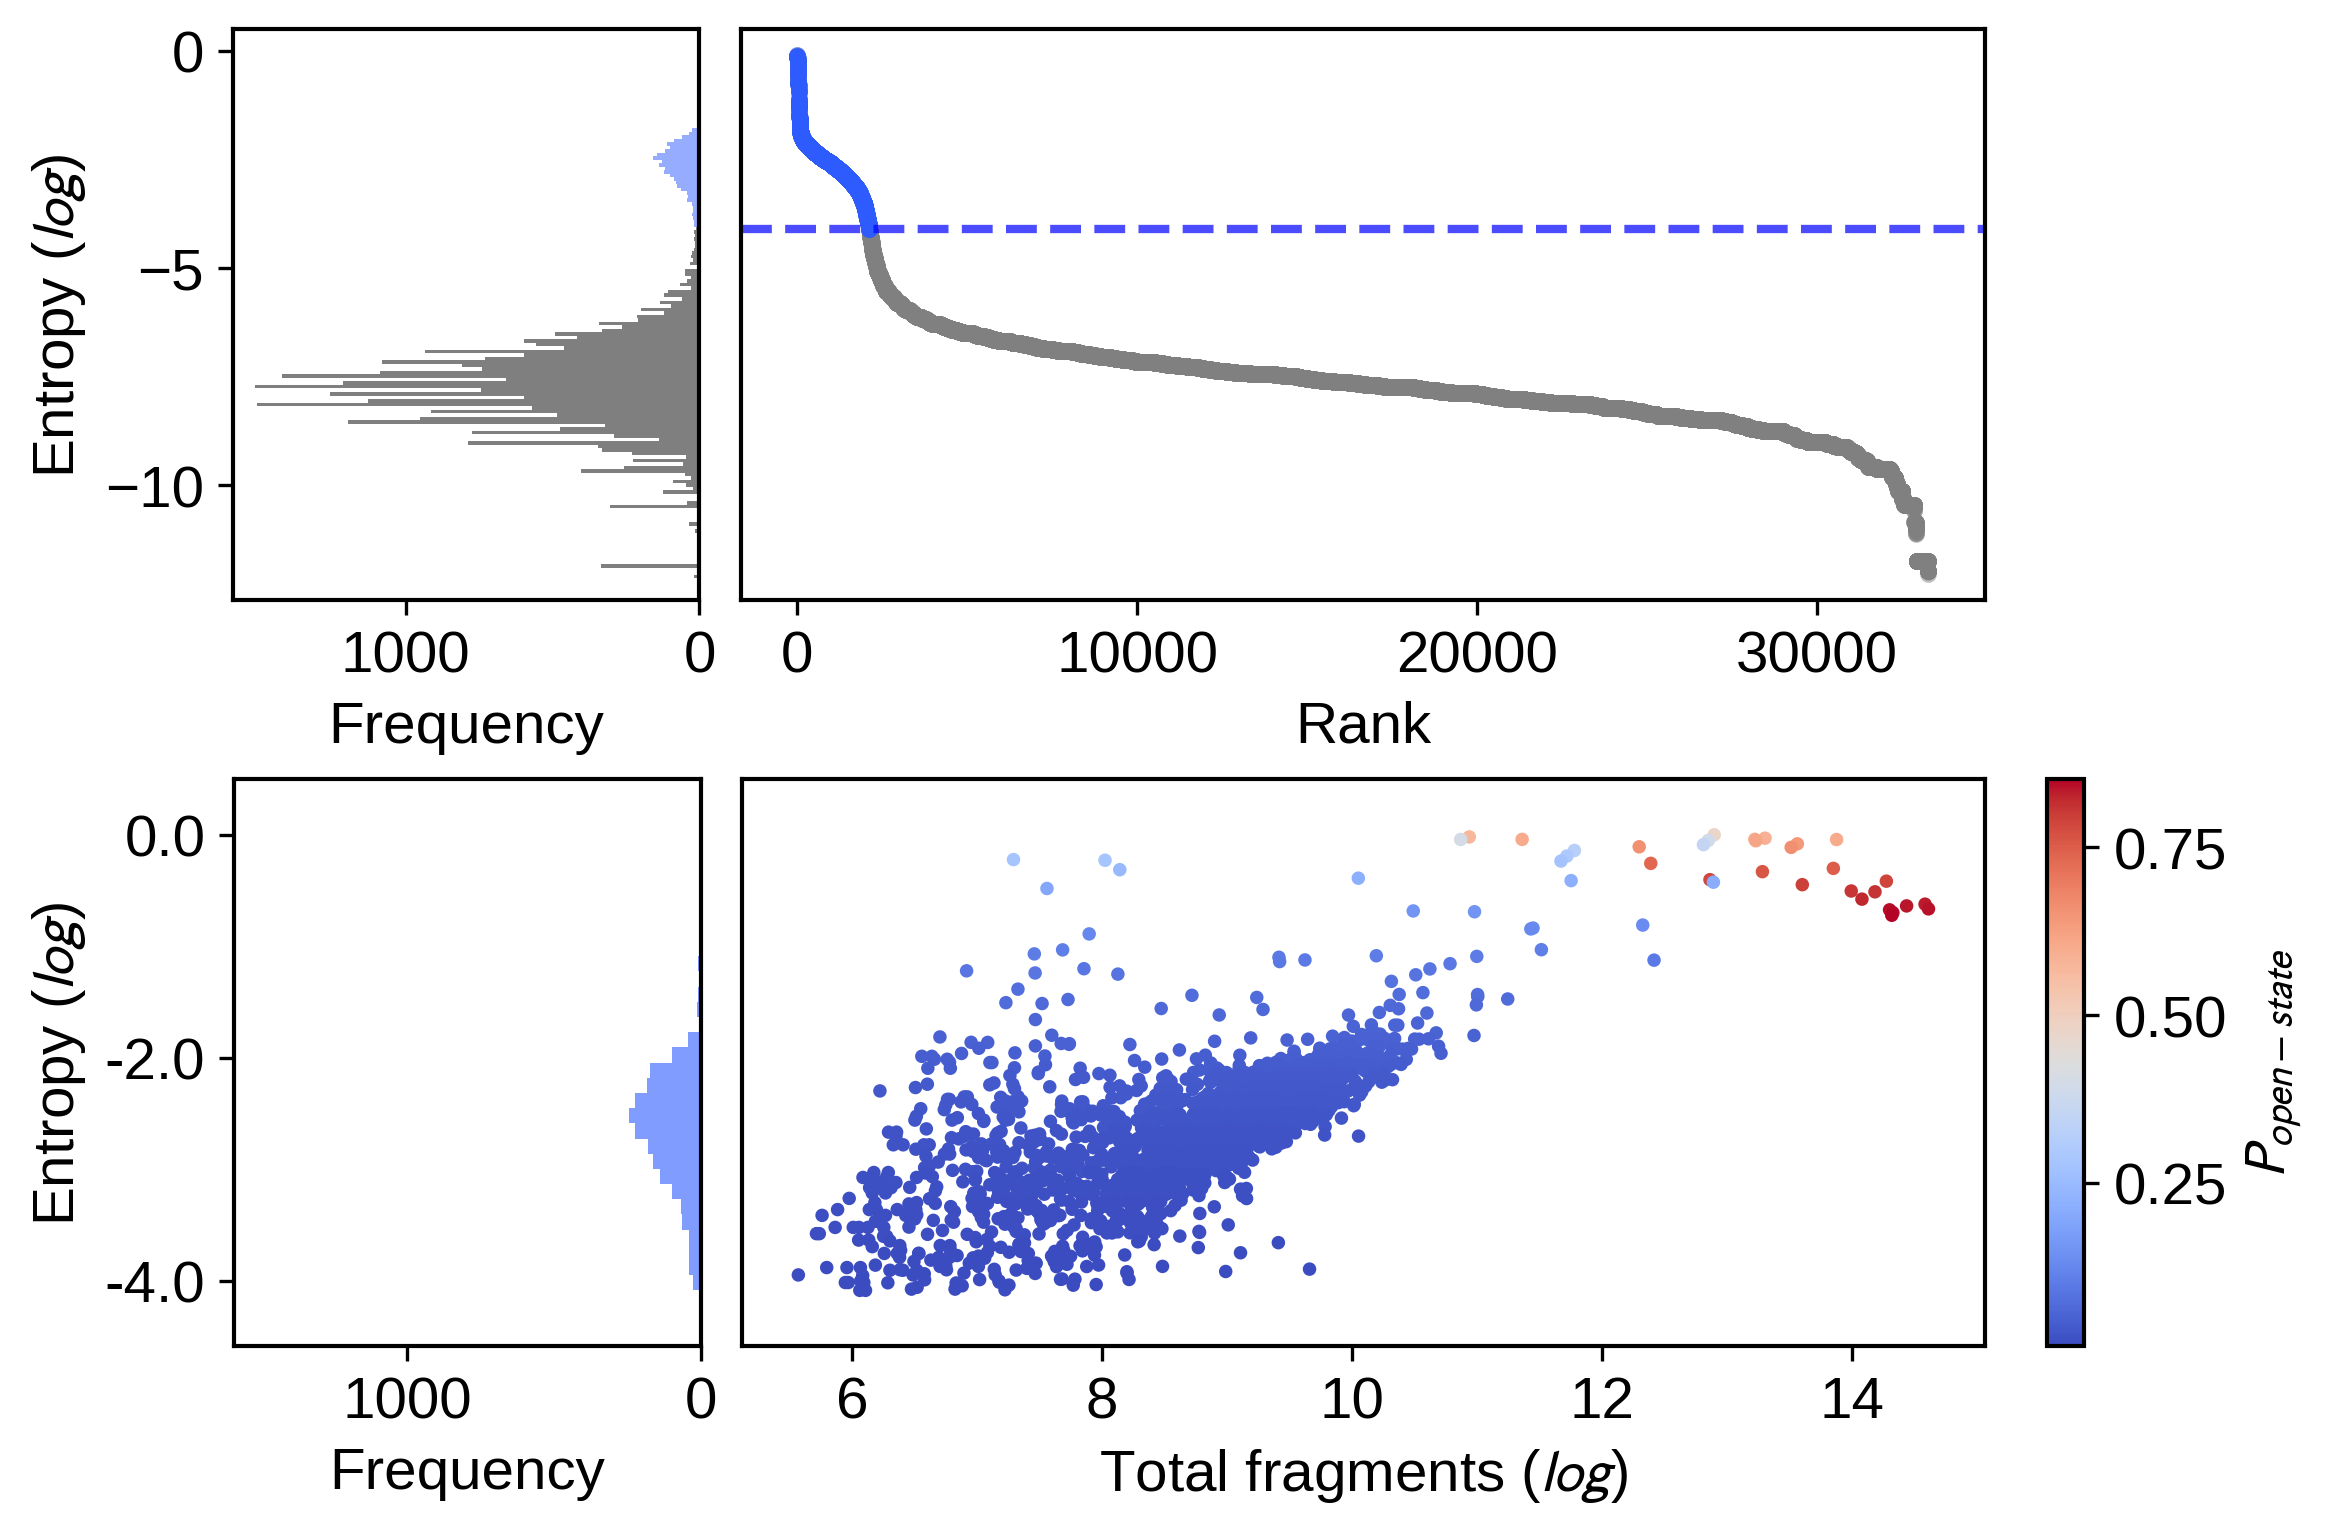

In [14]:
fig = plt.figure(layout="constrained", figsize=(6.6, 5))

# Create a top-level GridSpec with 3 rows
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1])

# --- Row 1 ---
gs0 = gs[0].subgridspec(1, 2, width_ratios=[3, 8])
ax1 = fig.add_subplot(gs0[0, 0])
ax2 = fig.add_subplot(gs0[0, 1])

# --- Row 2 ---
gs1 = gs[1].subgridspec(1, 2, width_ratios=[3, 8])
ax3 = fig.add_subplot(gs1[0, 0],sharex=ax1)
ax4 = fig.add_subplot(gs1[0, 1])


entropy_min, entropy_max = entropy_all['log_entropy'].min(), entropy_all['log_entropy'].max()

# ax1
n, bins, patches = ax1.hist(entropy_all['log_entropy'], bins=150, alpha=0.5, color='black', 
              orientation='horizontal')
for patch in patches:
    if patch.get_y() >= entropy_cutoff:
        patch.set_facecolor('#2E5BFF')
        patch.set_alpha(0.5) 
ax1.set_ylim(entropy_min - 0.5, entropy_max + 0.5)
ax1.invert_xaxis()
ax1.set_xlabel('Frequency')
ax1.set_ylabel('Entropy ($log$)')
# ax2 
sorted_log2entropy_list = entropy_all['log_entropy'].dropna().sort_values(ascending=False).values
rank_list = np.arange( len(sorted_log2entropy_list) )
entropy_cutoff = entropy_df['log_entropy'].min()
above_cutoff_index = sorted_log2entropy_list >= entropy_cutoff
s2 = ax2.plot(rank_list, sorted_log2entropy_list,  'o', markersize=3, color='grey', alpha=0.5)
s2 = ax2.plot(rank_list[above_cutoff_index], sorted_log2entropy_list[above_cutoff_index],  'o', markersize=3, color='#2E5BFF', alpha=0.5)
ax2.axhline(entropy_cutoff, color='blue', linestyle='--', alpha=0.7)
ax2.set_xlabel('Rank')
# set ax2 x-ticks to be none
ax2.set_yticks([])

# ax3 
DNAdebris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'YES'
noDNAdebris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'NO'
s3 = ax3.hist(entropy_w_DNAdebrisflag_df['log_entropy'][noDNAdebris_index], bins=30, alpha=0.6, color="#2E5BFF",
              orientation='horizontal')
s3_a = ax3.hist(entropy_w_DNAdebrisflag_df['log_entropy'][DNAdebris_index],  alpha=1, color="#E4440A",
              orientation='horizontal')
ax3.set_ylim(entropy_cutoff - 0.5, entropy_max + 0.5)
ax3.set_xlim(ax1.get_xlim()[::-1]) # align x-axis limits with ax1
ax3.invert_xaxis()
ax3.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax3.set_ylabel('Entropy ($log$)')
ax3.set_xlabel('Frequency')

# ax4 
s4 = ax4.scatter(entropy_w_DNAdebrisflag_df['log_total_fragments'], entropy_w_DNAdebrisflag_df['log_entropy'],
                 c = 1 - entropy_w_DNAdebrisflag_df['P_closed_state'],
                 alpha=1, s=5, cmap='coolwarm' )# cmap='viridis_r' )
ax4.set_xlabel('Total fragments ($log$)')
ax4.set_yticklabels([]) # hide y-ticks
ax4.set_ylim(entropy_cutoff - 0.5, entropy_max + 0.5)
ax4.set_yticks([]) # hide y-ticks


from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Create colorbar axes OUTSIDE ax2 [x_offset, y_offset, width, height]
cax2 = inset_axes(ax4,
                   width="3%",  
                   height="100%",
                   loc='lower left',
                   bbox_to_anchor=(1.05, 0., 1, 1), # (x, y, width, height) relative to ax2
                   bbox_transform=ax4.transAxes,
                   borderpad=0)
fig.colorbar(s4, cax=cax2, label='$P_{open-state}$')

fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig1_p1.png'), dpi=300, bbox_inches='tight')



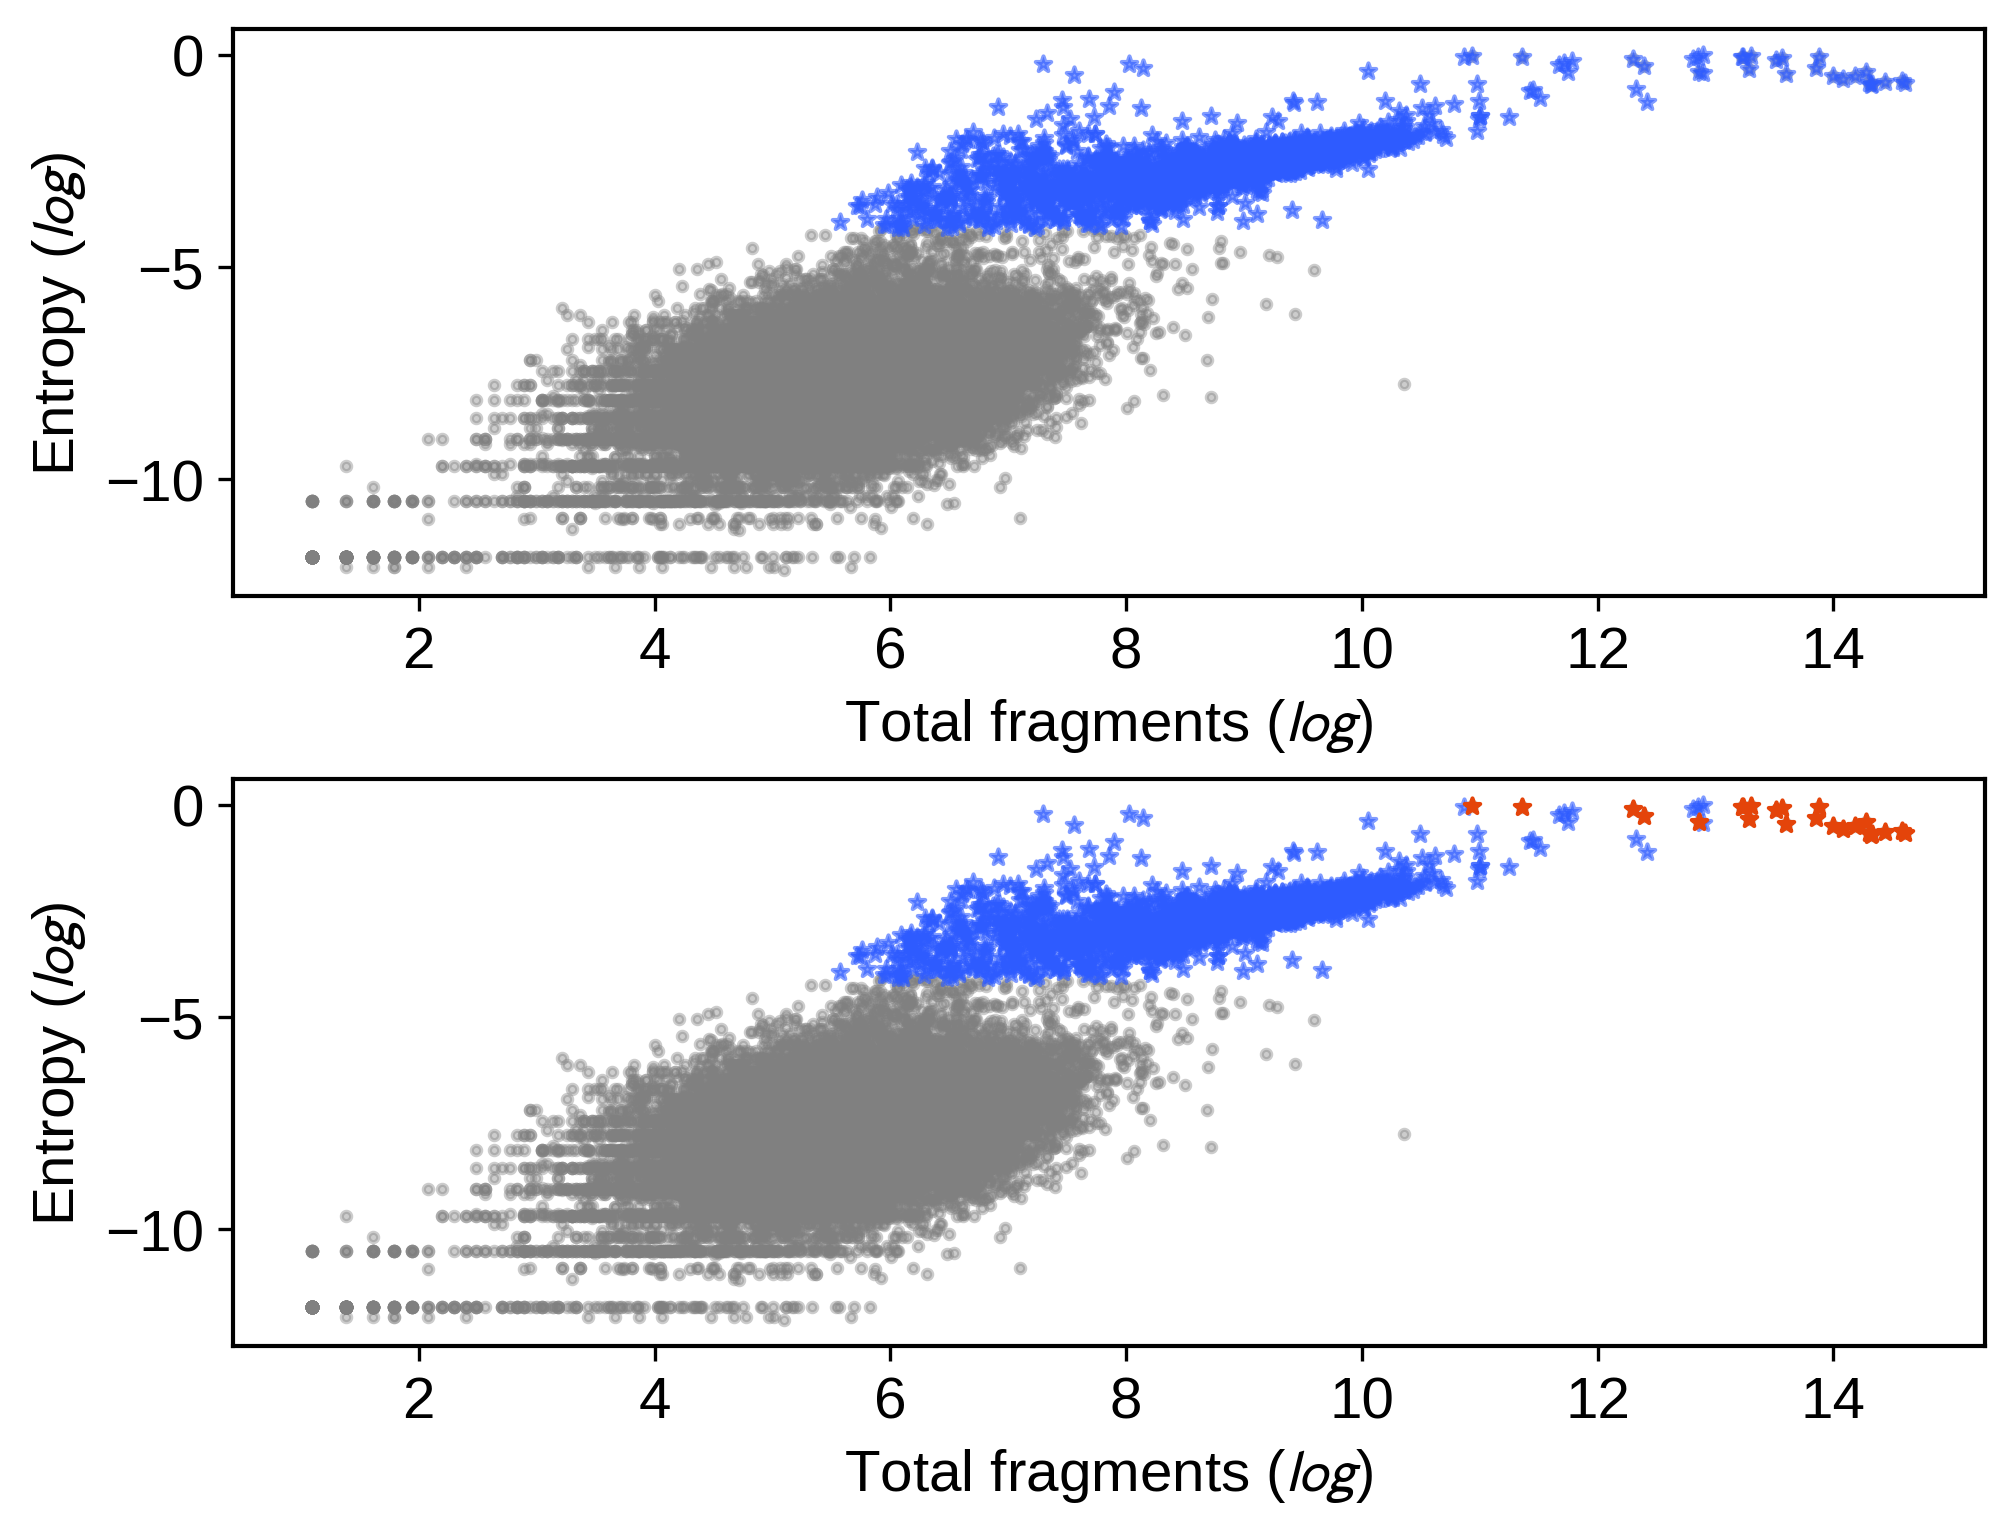

In [15]:
fig = plt.figure(layout="constrained", figsize=(6.6, 5))

# Create a GridSpace with 2 columns and specify width ratios
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1])

filtered_out_index = ~entropy_all.index.isin(entropy_df.index)
filtered_in_index = entropy_all.index.isin(entropy_df.index)
cellular_debris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'YES'

ax0 = fig.add_subplot(gs[0, 0]) 
s0 = ax0.scatter(entropy_all['log_total_fragments'][filtered_out_index], entropy_all['log_entropy'][filtered_out_index], 
                 c ='grey', alpha=0.4, s=5)
s0_ = ax0.scatter(entropy_w_DNAdebrisflag_df['log_total_fragments'], entropy_w_DNAdebrisflag_df['log_entropy'],
                 c ='#2E5BFF', alpha=0.6, s=15, marker='*',
                 label='Filtered Barcodes', )


ax1 = fig.add_subplot(gs[1, 0])
s = ax1.scatter(entropy_all['log_total_fragments'][filtered_out_index], entropy_all['log_entropy'][filtered_out_index], 
                 c ='grey', alpha=0.4, s=5)
ax1.scatter(entropy_df['log_total_fragments'], entropy_df['log_entropy'], 
                 c ='#2E5BFF', alpha=0.6, s=15, marker='*',
                 label='Filtered Barcodes', )

ax1.scatter(entropy_w_DNAdebrisflag_df['log_total_fragments'][cellular_debris_index], entropy_w_DNAdebrisflag_df['log_entropy'][cellular_debris_index],
             c ='#E4440A', alpha=1, s=15, marker='*',
             label='Cellular Debris', )

for ax in [ax0, ax1]:
    ax.set_xlabel('Total fragments ($log$)')
    ax.set_ylabel('Entropy ($log$)')

fig.savefig(os.path.join(os.getcwd(), '_figures', 'fig1_p2.png'), dpi=300)


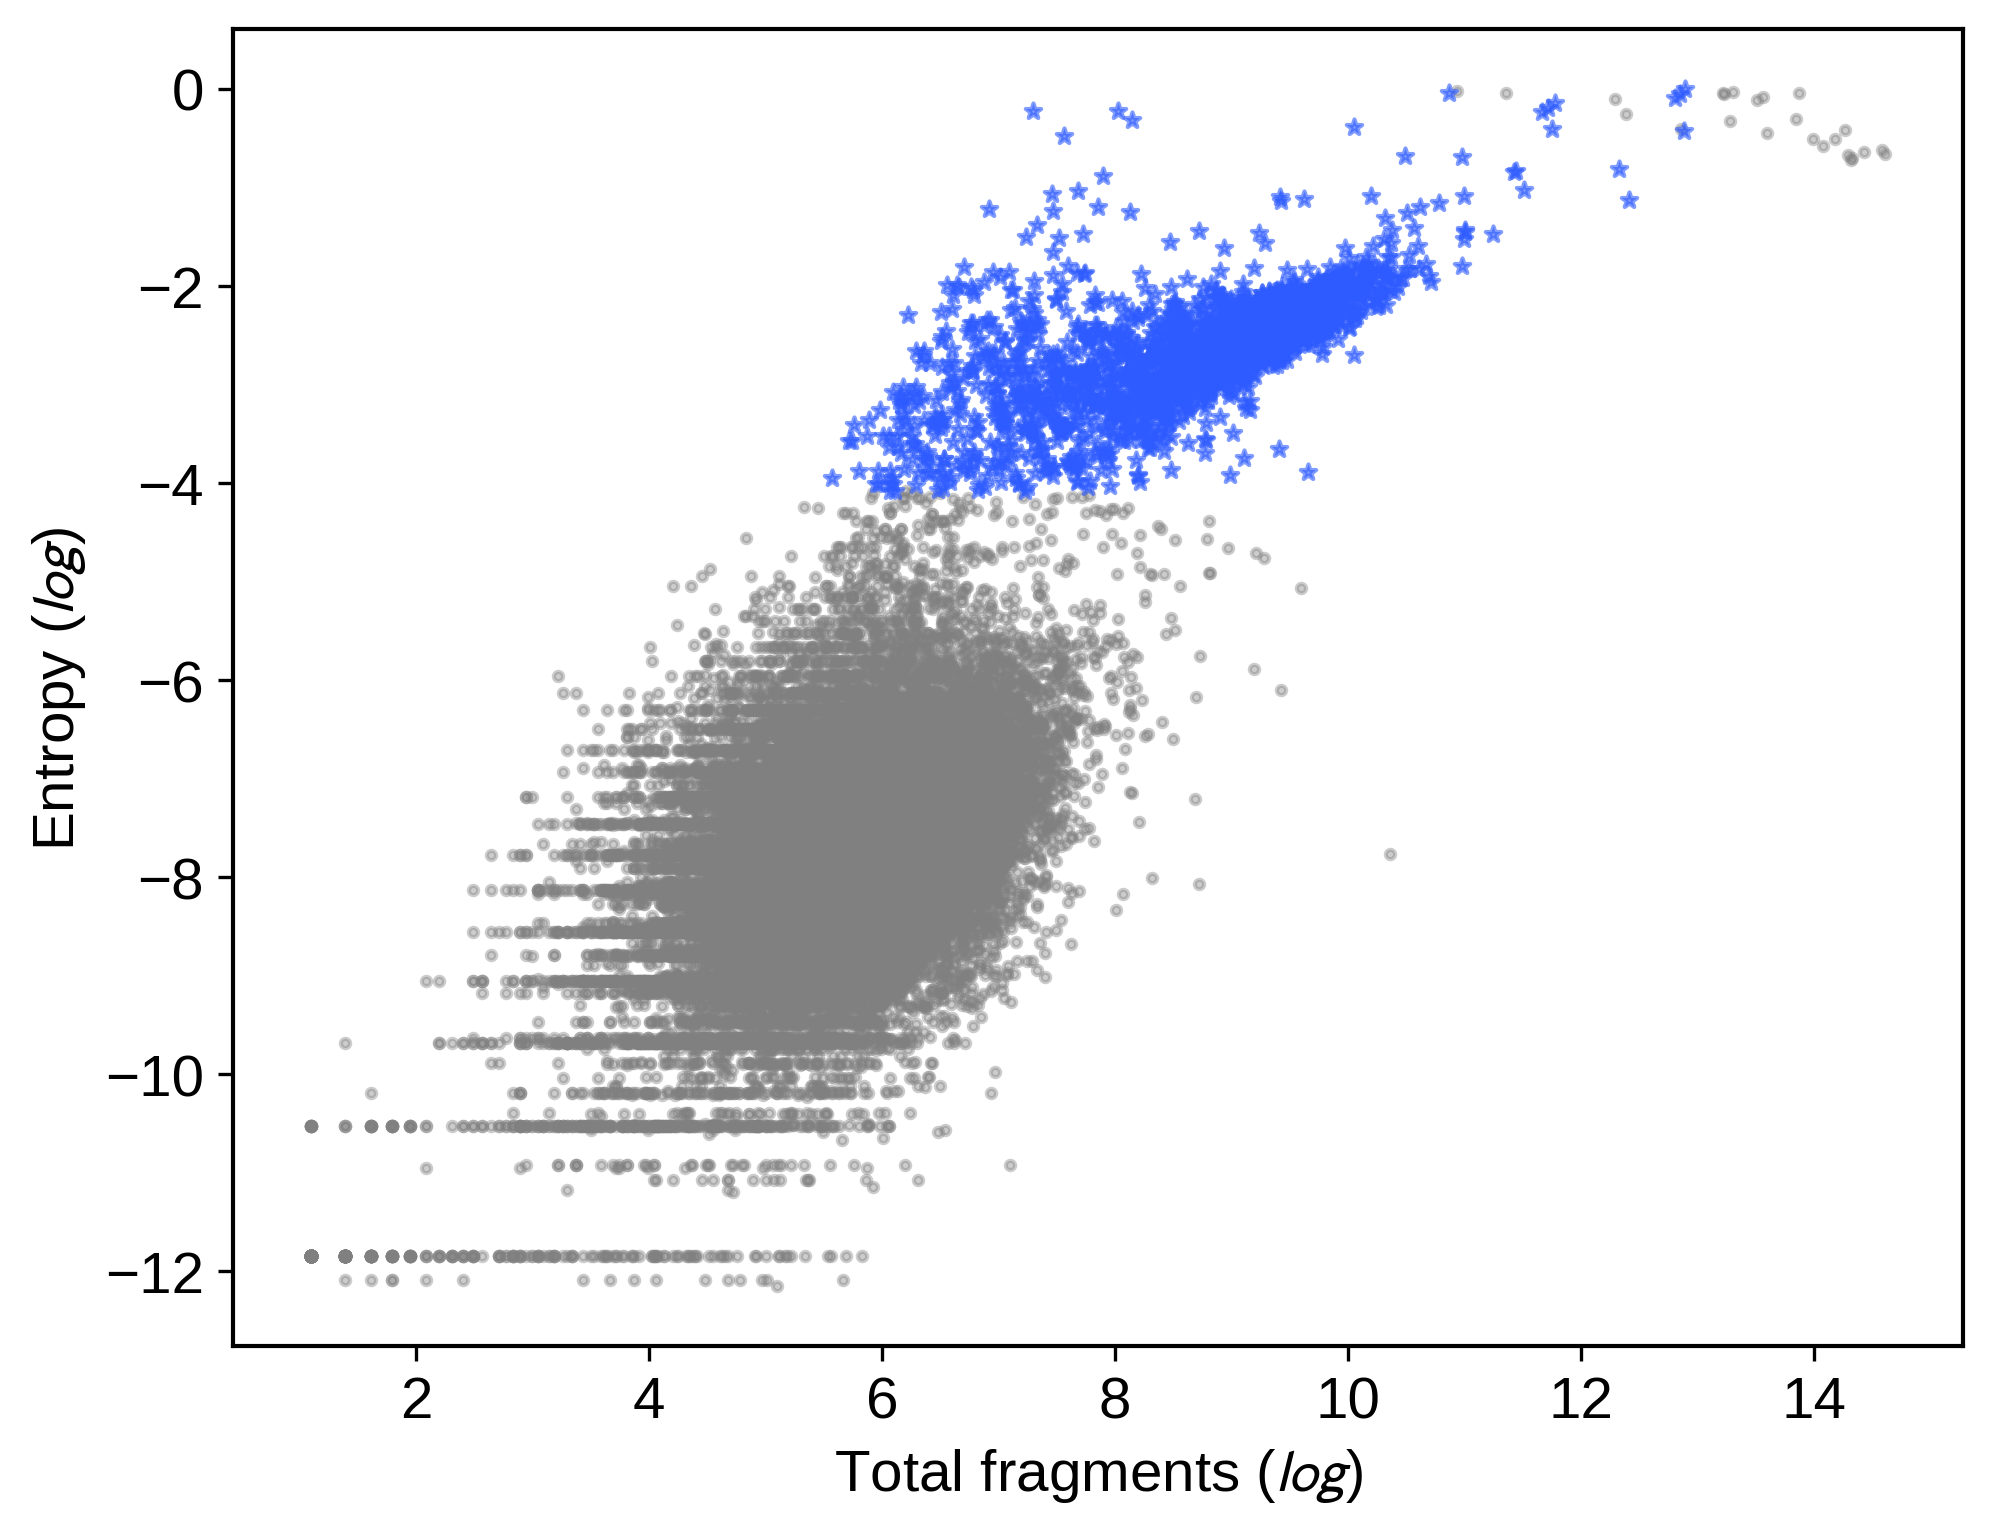

In [16]:
fig = plt.figure(layout="constrained", figsize=(6.6, 5))

# Create a GridSpace with 2 columns and specify width ratios
gs = fig.add_gridspec(1, 2, width_ratios=[0.1, 8])

# blank = fig.add_subplot(gs[0, 0])
# blank.axis('off')  # Hide axes for the blank subplot
ax1 = fig.add_subplot(gs[0, 1])

filtered_out_index = ~entropy_all.index.isin(entropy_df.index)
filtered_in_index = entropy_all.index.isin(entropy_df.index)
s = ax1.scatter(entropy_all['log_total_fragments'][filtered_out_index], entropy_all['log_entropy'][filtered_out_index], 
                 c ='grey', alpha=0.4, s=5)
ax1.set_xlabel('Total fragments ($log$)')
ax1.set_ylabel('Entropy ($log$)')
ax1.scatter(entropy_df['log_total_fragments'], entropy_df['log_entropy'], 
                 c ='#2E5BFF', alpha=0.6, s=15, marker='*',
                 label='Filtered Barcodes', )
#ax.legend(bbox_to_anchor=(1, 1), markerscale=3.0)

## Demonstration of the workflow of SADE

In [17]:
entropy_min, entropy_max = entropy_all['log_entropy'].min(), entropy_all['log_entropy'].max()

## Step1. Entropy under mixture distribution is calculated for each barcode 
(in entropy_all_file i.e., calculated_barcode_entropy_wDNAdebrisflag_df.tsv file) 

Text(0.5, 0.98, 'All barcodes with valid entropy in the experiment')

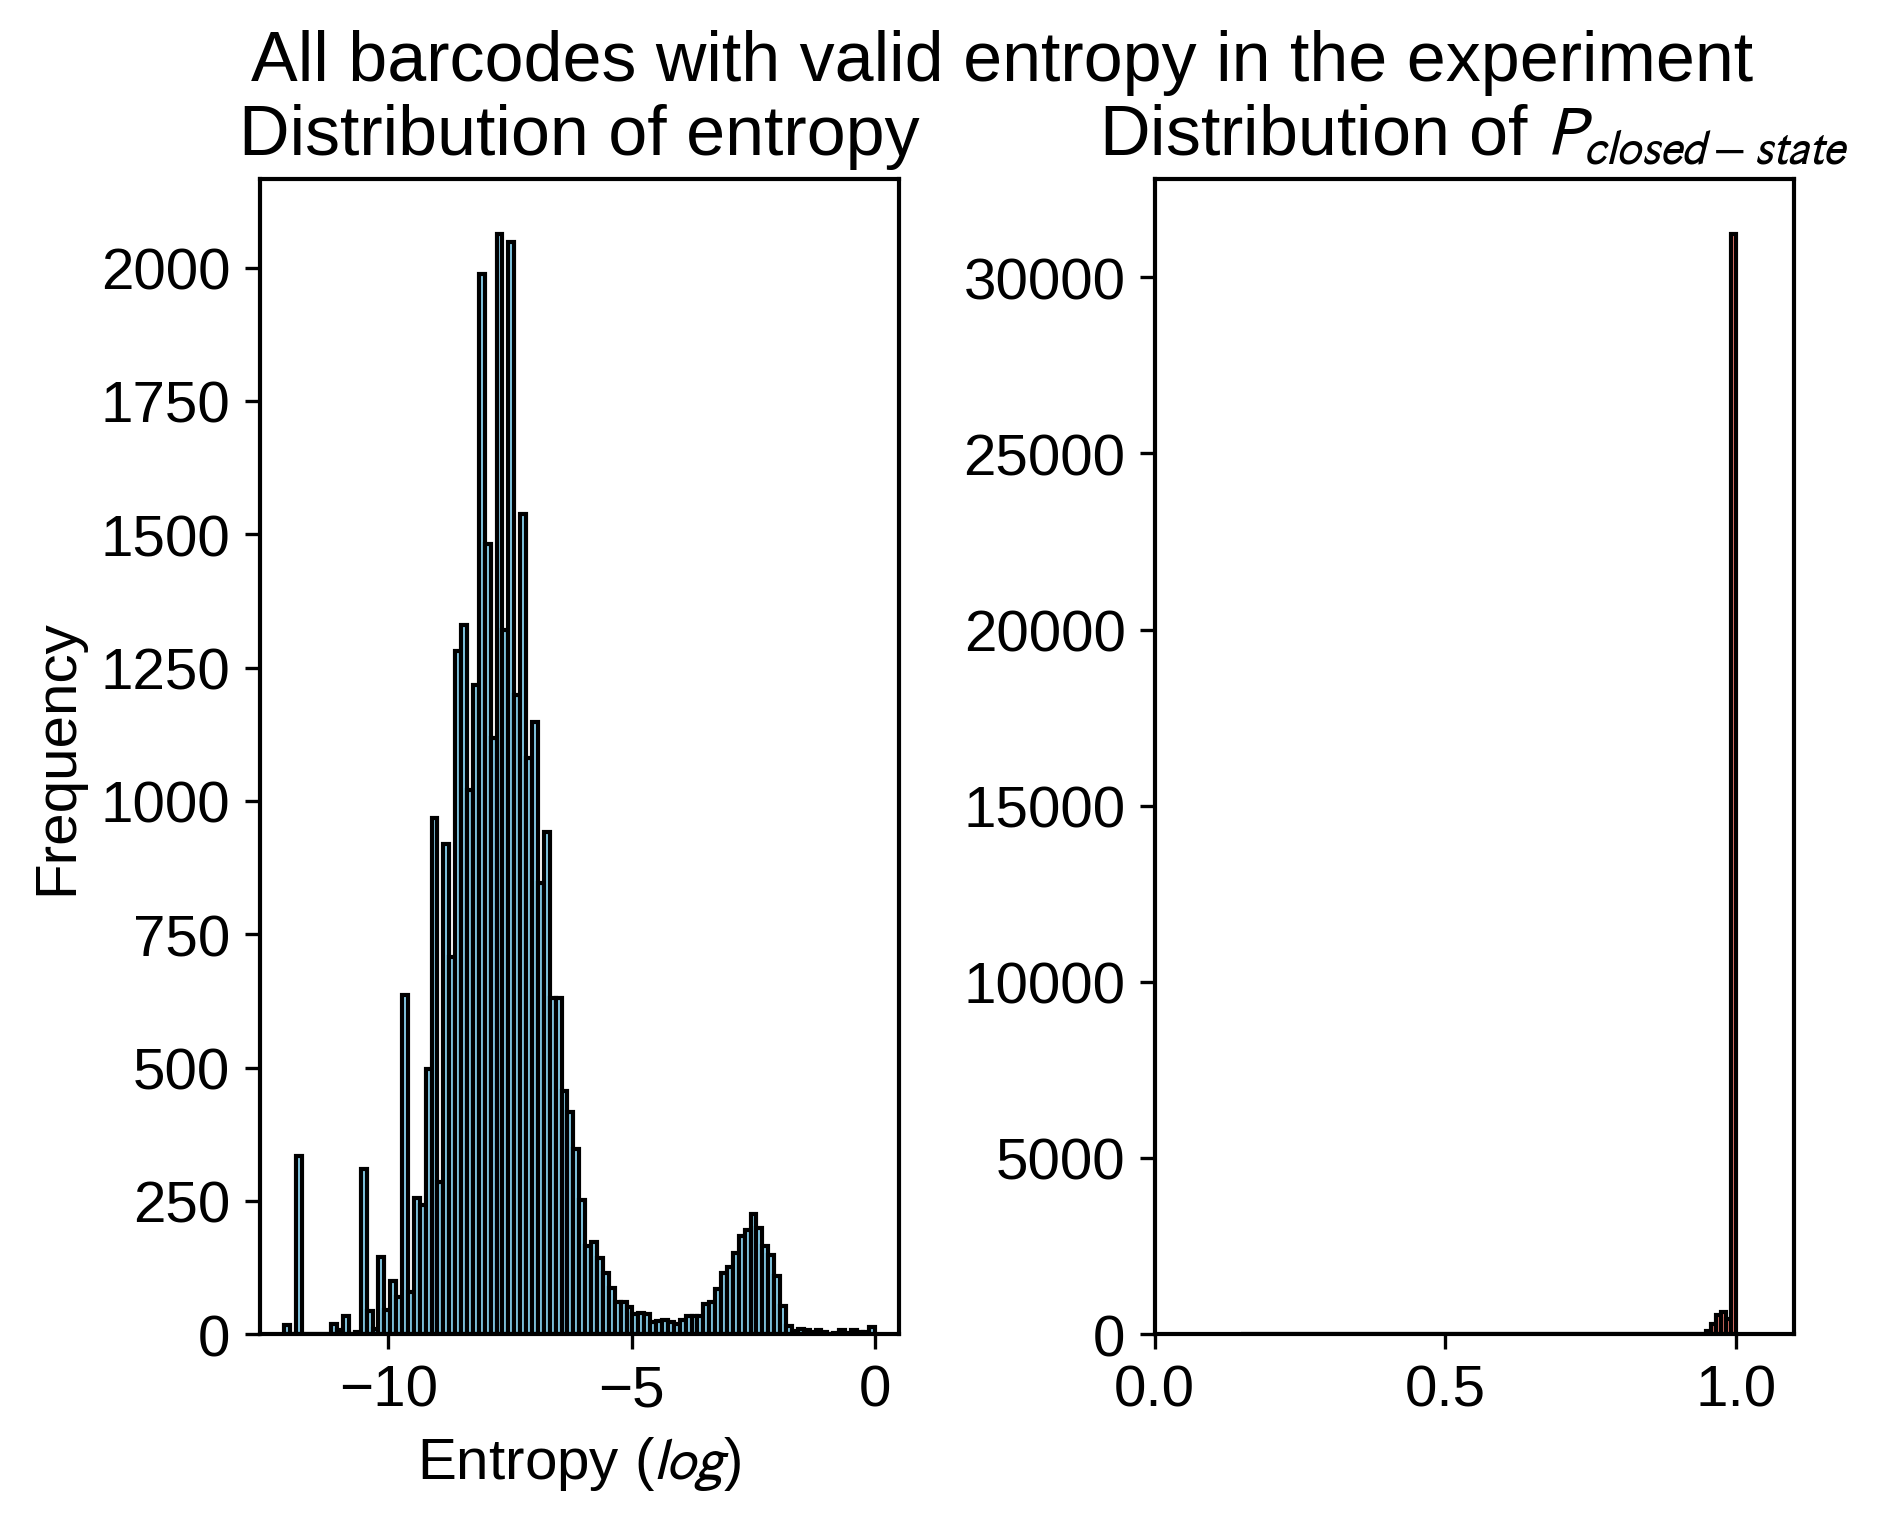

In [18]:
fig, ax = plt.subplots(ncols=2,  figsize=(6.6, 5), gridspec_kw={'wspace': 0.4})
_ = ax[0].hist(entropy_all['log_entropy'], bins=100, color='skyblue', edgecolor='black')
ax[0].set_xlabel('Entropy ($log$)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of entropy')
ax[0].set_xlim(entropy_min - 0.5, entropy_max + 0.5)

_ = ax[1].hist(entropy_all['P_closed_state'], bins=100, color='salmon', edgecolor='black')
ax[1].set_title('Distribution of $P_{closed-state}$')
ax[1].set_xlim(0, 1.1)

fig.suptitle('All barcodes with valid entropy in the experiment')

## Step 2. Smooth curved fitted to filter out empty barcodes/droplets
(in entropy_filtered_bc_w_DNAdebrisflag_df.tsv file)

Text(0.5, 0.98, 'Barcodes passed entropy threshold')

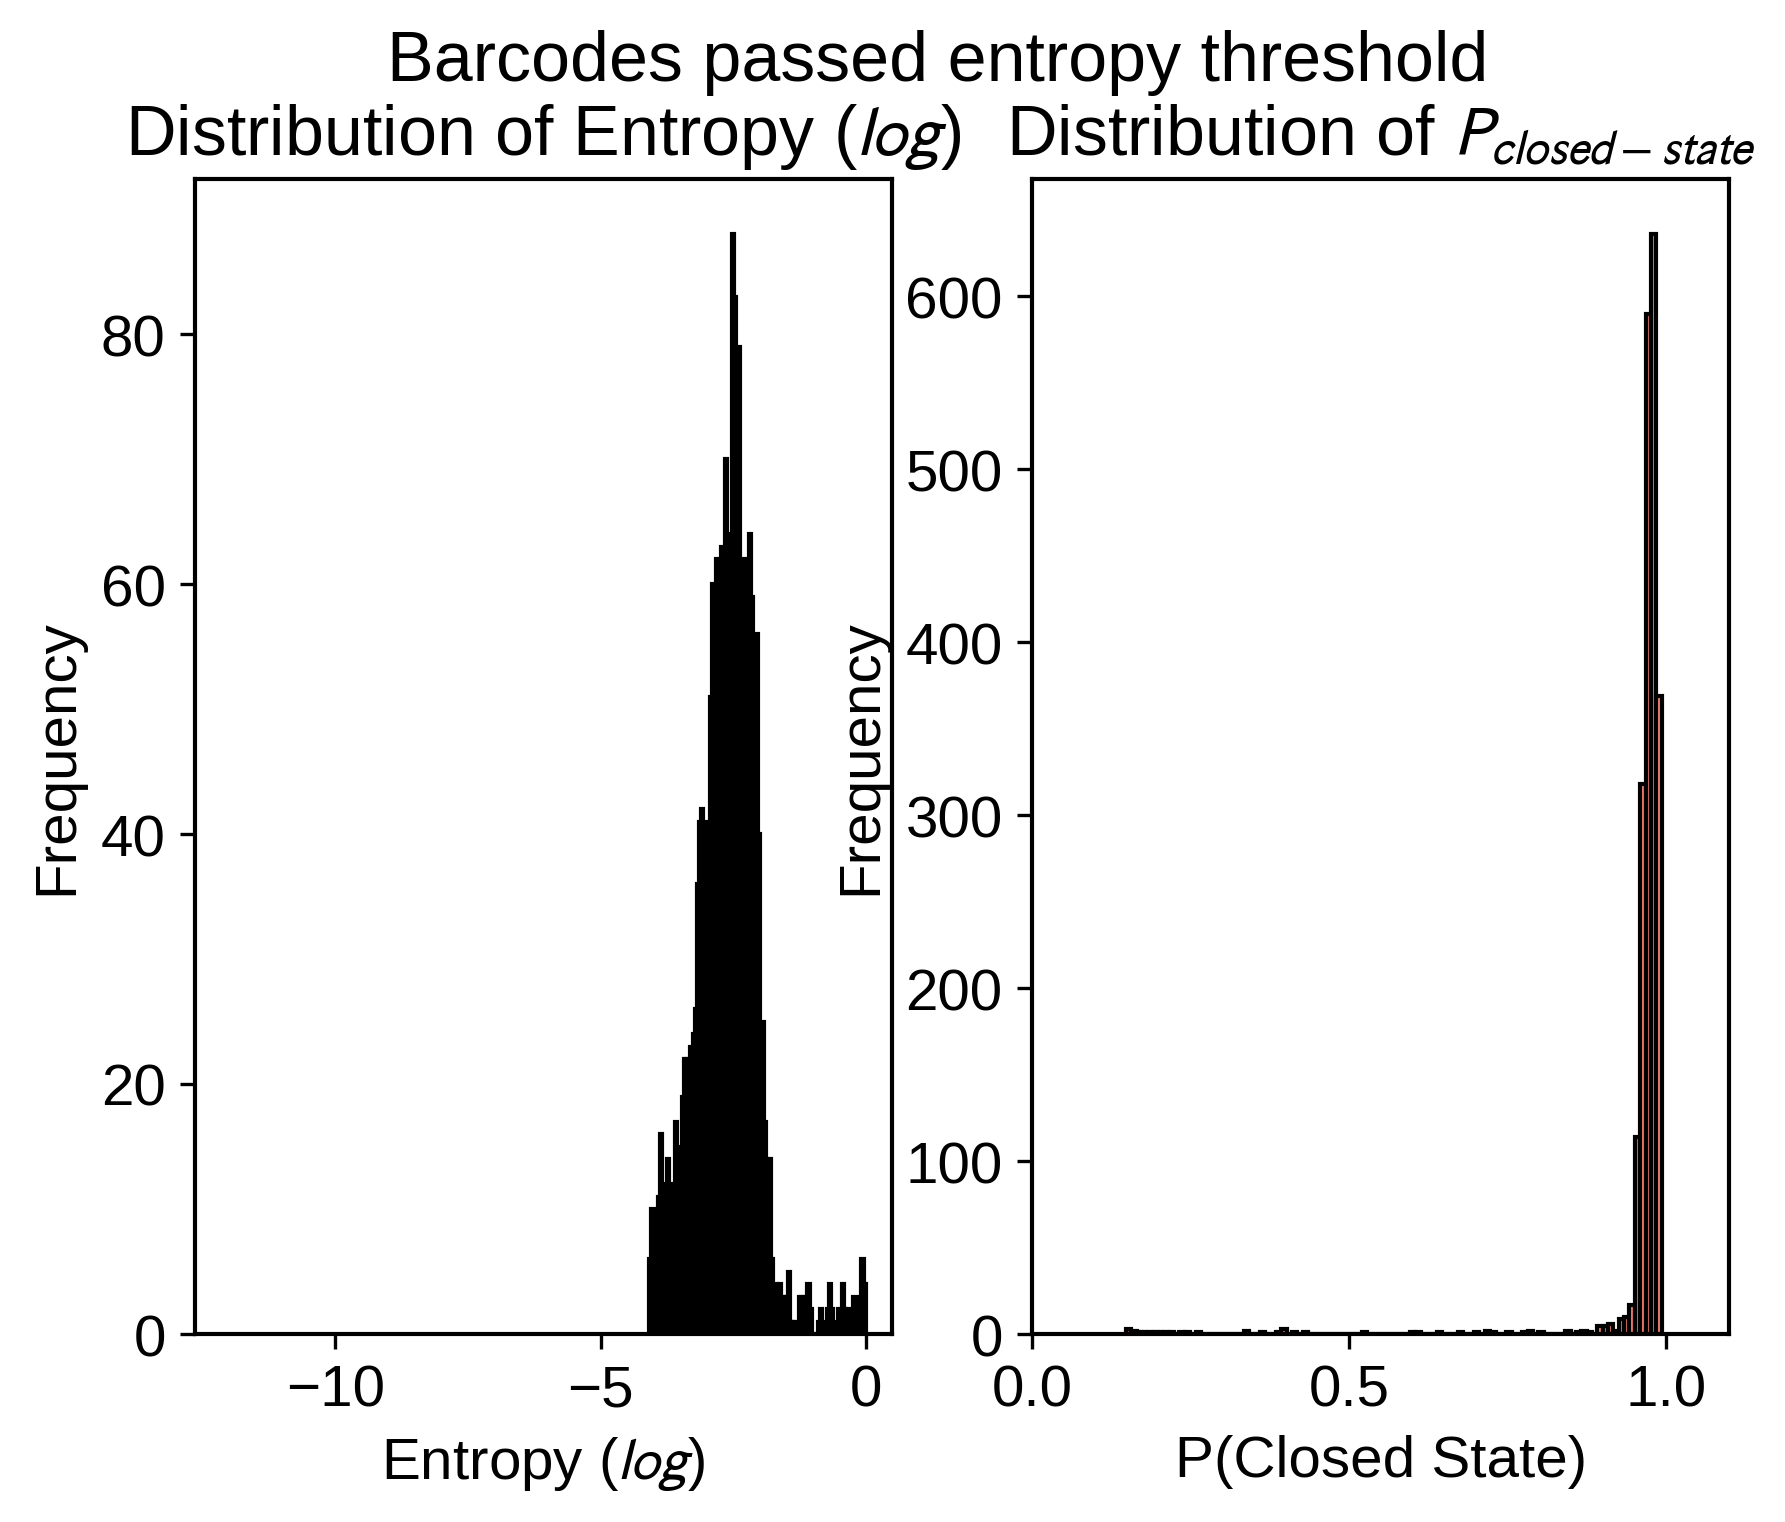

In [19]:
fig, ax = plt.subplots(ncols=2,  figsize=(6.6, 5))
_ = ax[0].hist(entropy_w_DNAdebrisflag_df['log_entropy'], bins=100, color='salmon', edgecolor='black')
ax[0].set_xlabel('Entropy ($log$)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Entropy ($log$)')
ax[0].set_xlim(entropy_min - 0.5, entropy_max + 0.5)


_ = ax[1].hist(entropy_w_DNAdebrisflag_df['P_closed_state'], bins=100, color='salmon', edgecolor='black')
ax[1].set_xlabel('P(Closed State)')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Distribution of $P_{closed-state}$')
ax[1].set_xlim(0, 1.1)

fig.suptitle('Barcodes passed entropy threshold')

## Step3. Filter out Cellular-debris using P-closed-state estimated in the mixture distribution at threshold 0.5

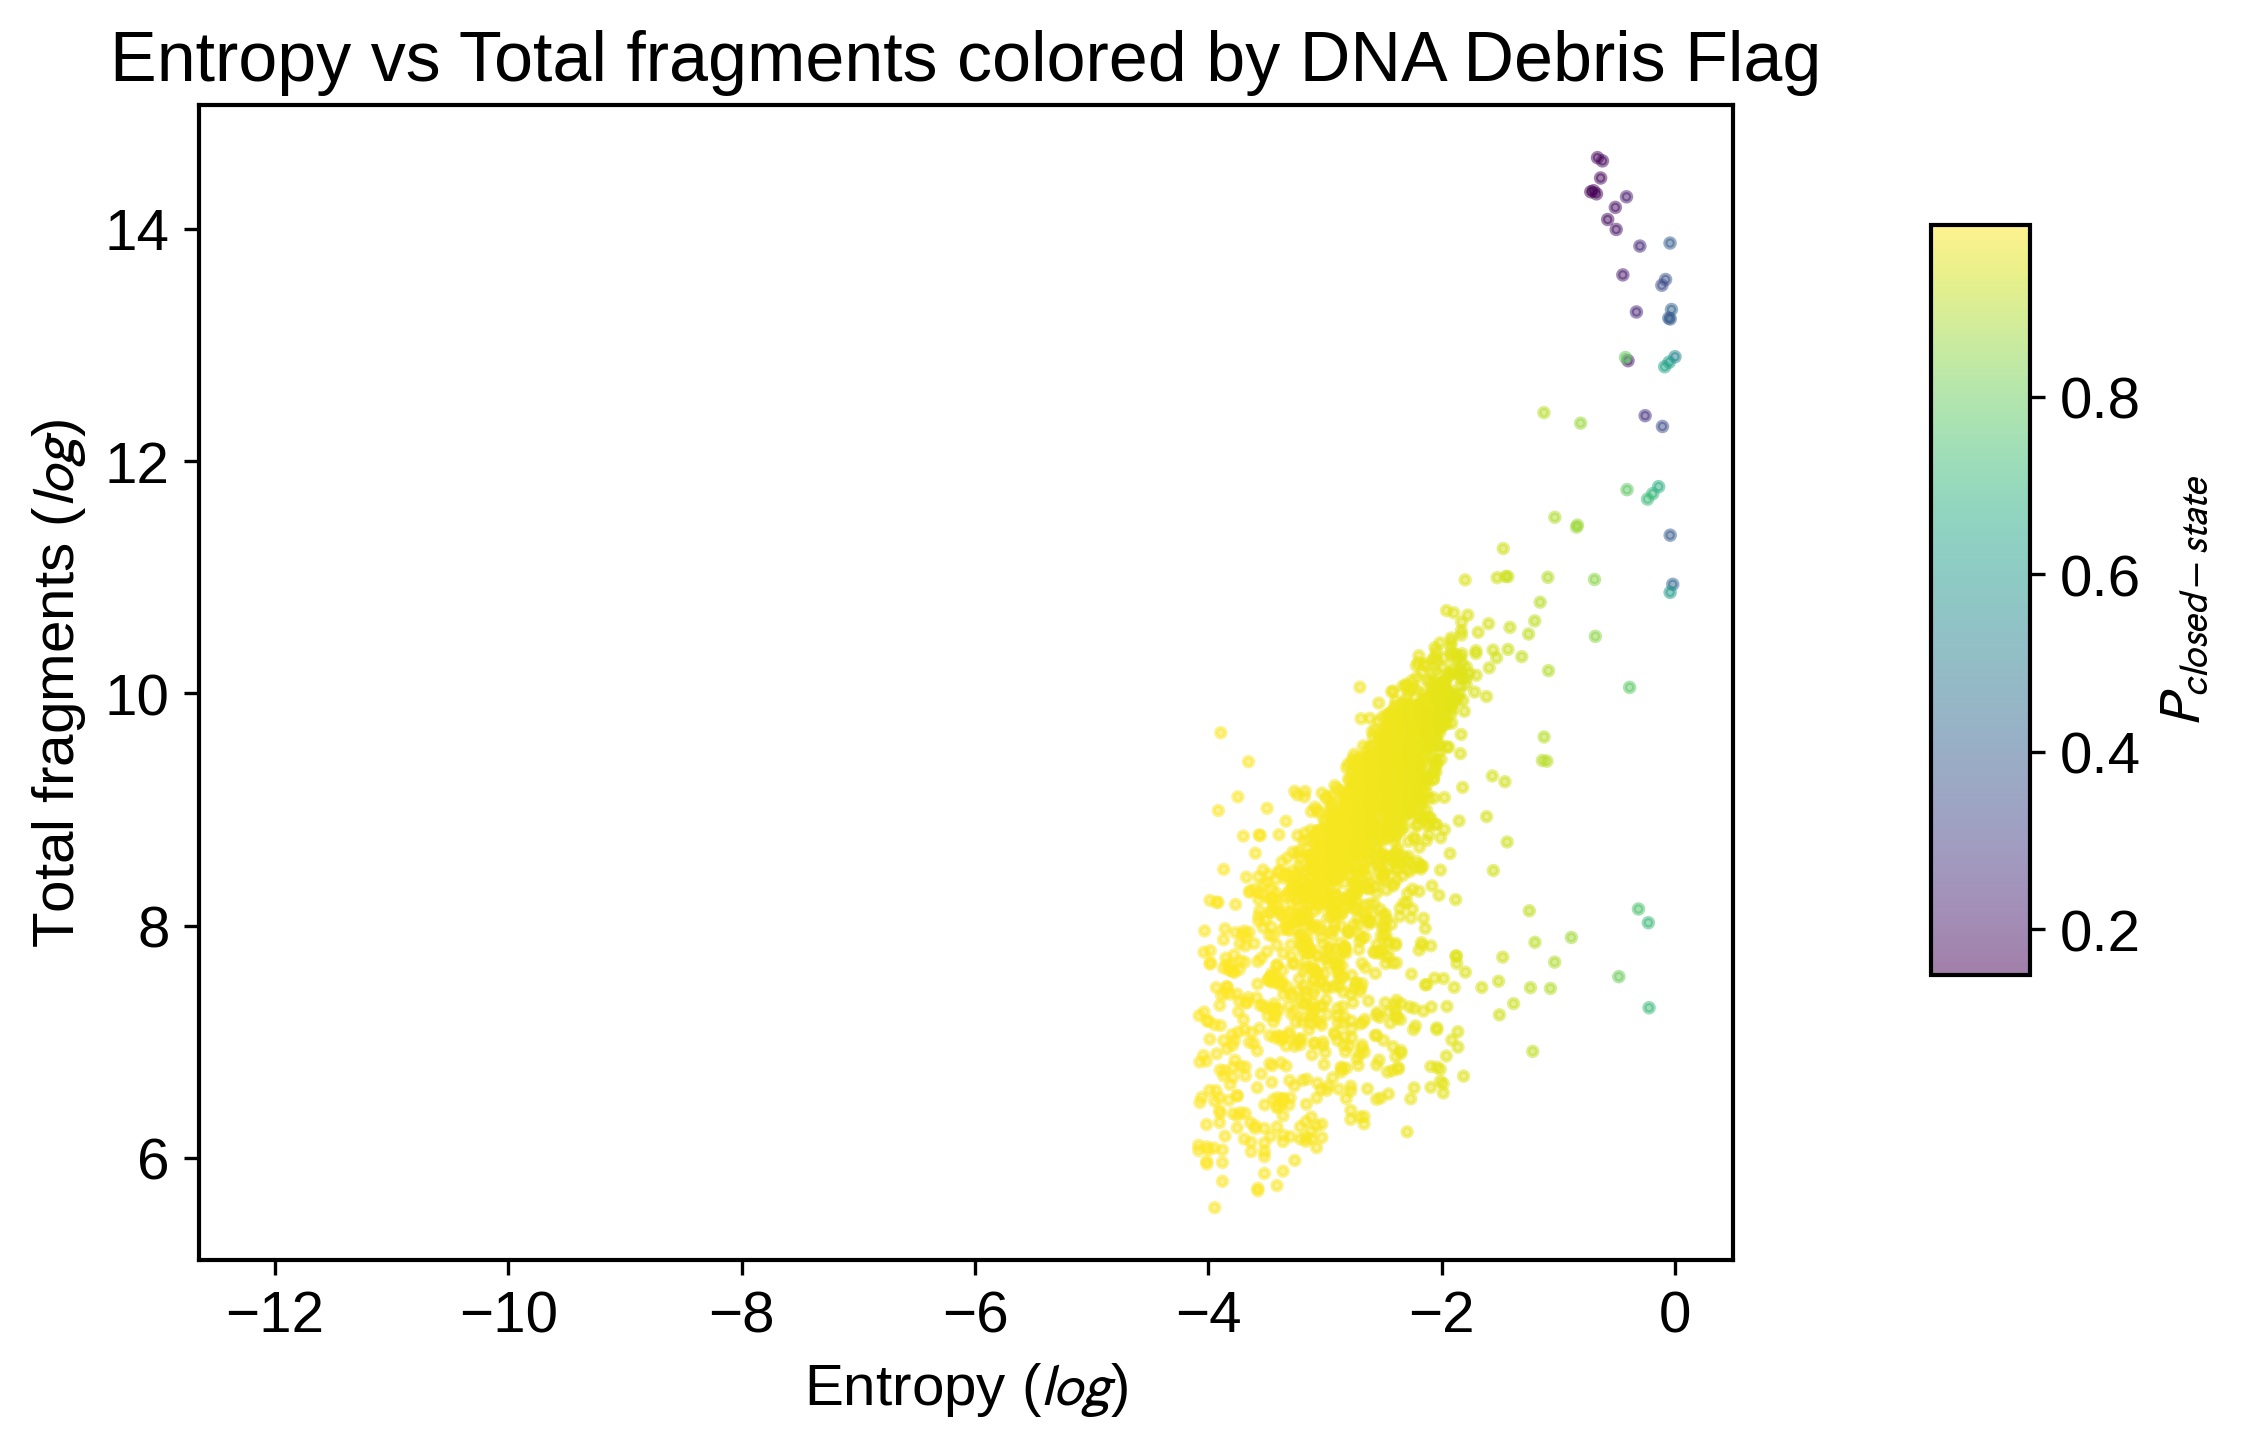

In [20]:
fig, ax = plt.subplots(figsize=(6.6, 5))
s1 = ax.scatter(entropy_w_DNAdebrisflag_df['log_entropy'], entropy_w_DNAdebrisflag_df['log_total_fragments'], 
                c = entropy_w_DNAdebrisflag_df['P_closed_state'],
                alpha=0.5, s=5,  label='No DNA Debris')

ax.set_xlabel('Entropy ($log$)')
ax.set_ylabel('Total fragments ($log$)')
ax.set_title('Entropy vs Total fragments colored by DNA Debris Flag')
ax.set_xlim(entropy_min - 0.5, entropy_max + 0.5)

# [x0, y0, width, height]
cax = fig.add_axes([1., 0.3, 0.05, 0.5]) 
cbar = fig.colorbar(s1, cax=cax, orientation='vertical', label='$P_{closed-state}$')

(-12.650440519823439, 0.4973389106816315)

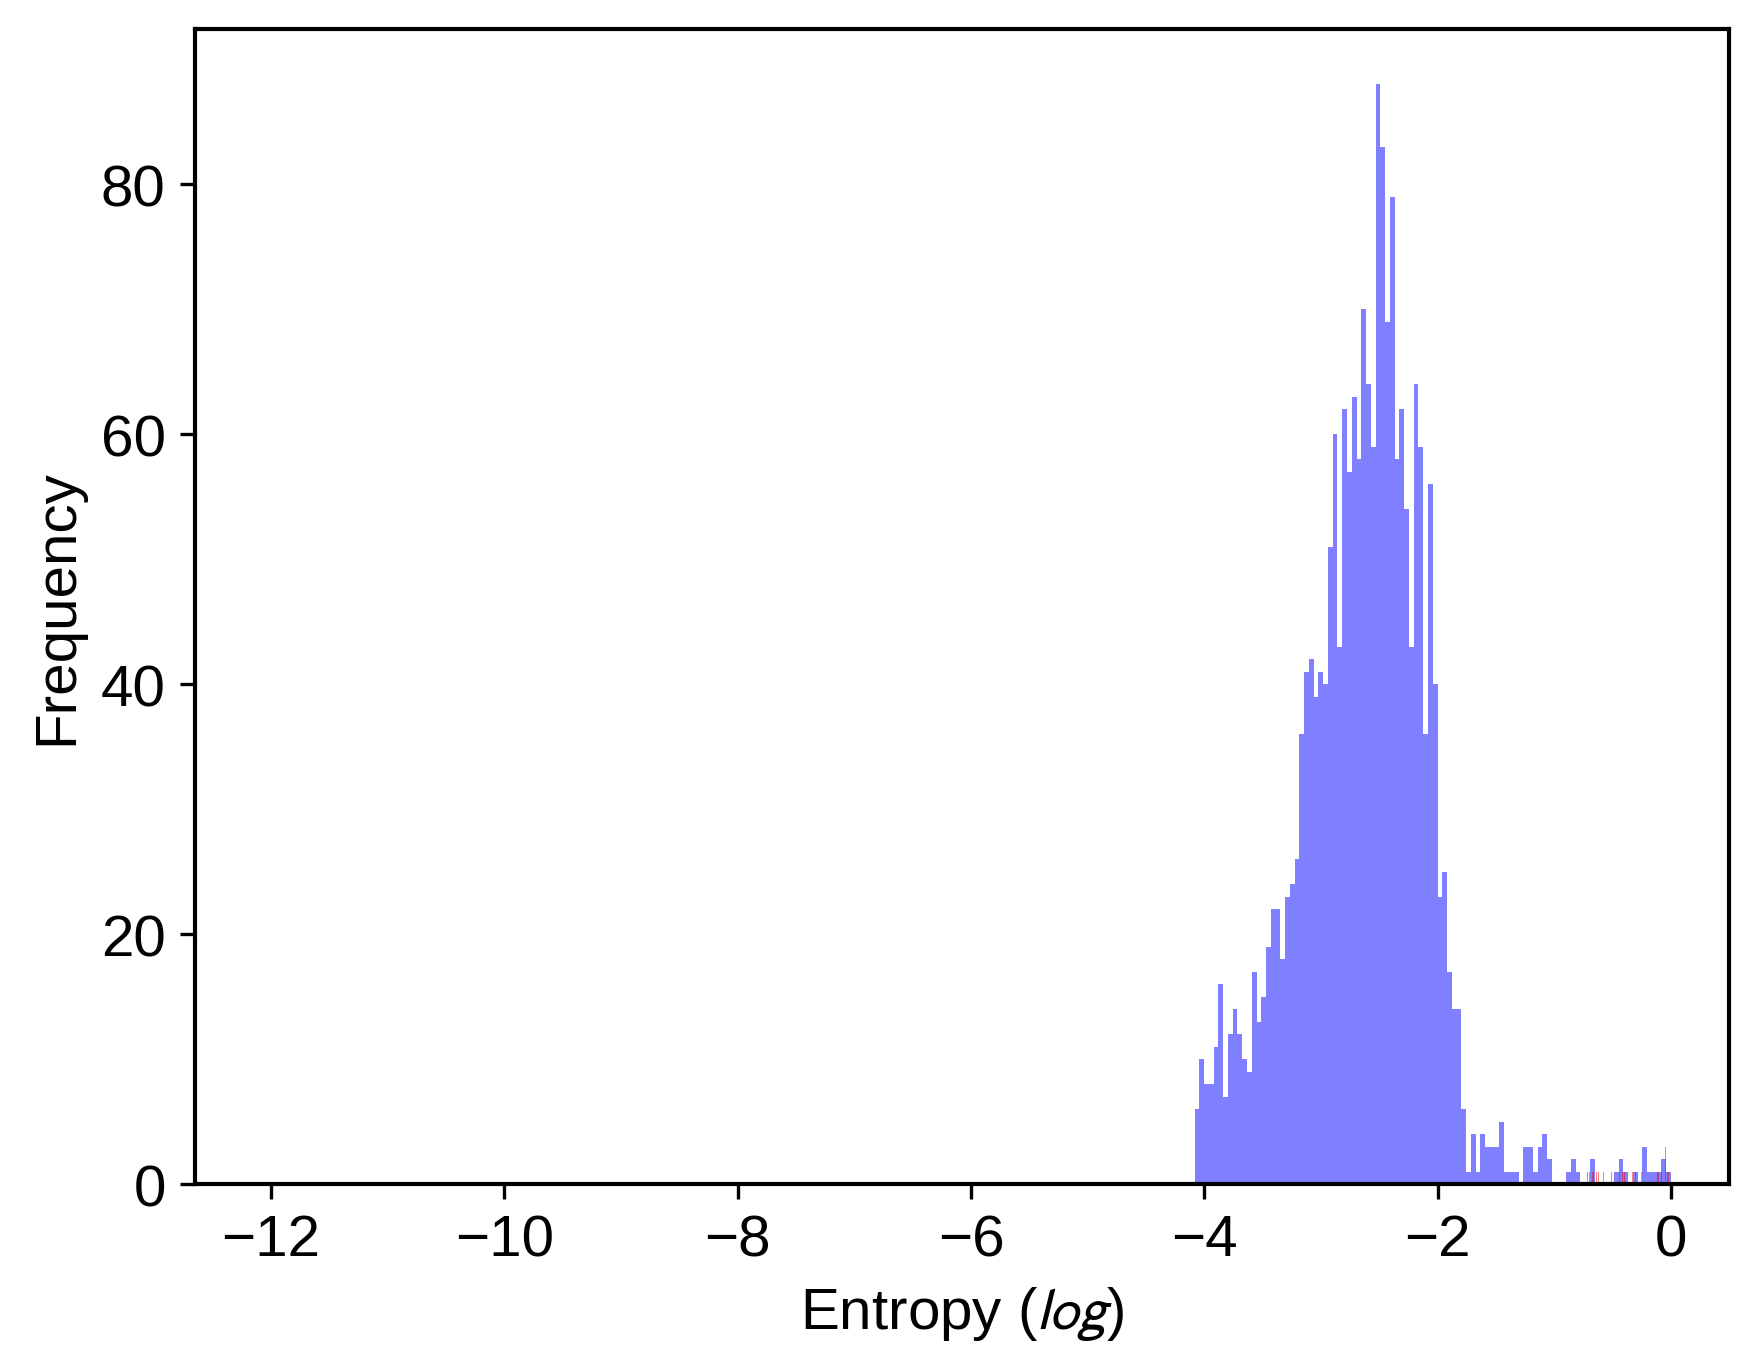

In [21]:
fig, ax = plt.subplots(figsize=(6.6, 5))
DNA_debris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'YES'
noDNA_debris_index = entropy_w_DNAdebrisflag_df['DNA_debris'] == 'NO'
s1 = ax.hist(entropy_w_DNAdebrisflag_df['log_entropy'][noDNA_debris_index], bins=100,
                alpha=0.5,color='blue', label='No DNA Debris')
s2 = ax.hist(entropy_w_DNAdebrisflag_df['log_entropy'][DNA_debris_index], bins=100,
                alpha=0.5,color='red', label='DNA Debris')

ax.set_xlabel('Entropy ($log$)')
ax.set_ylabel('Frequency')
ax.set_xlim(entropy_min - 0.5, entropy_max + 0.5)


Text(0.5, 1.0, 'Scatter Plot of Total fragments ($log$) vs P(Closed State) colored by DNA Debris Flag')

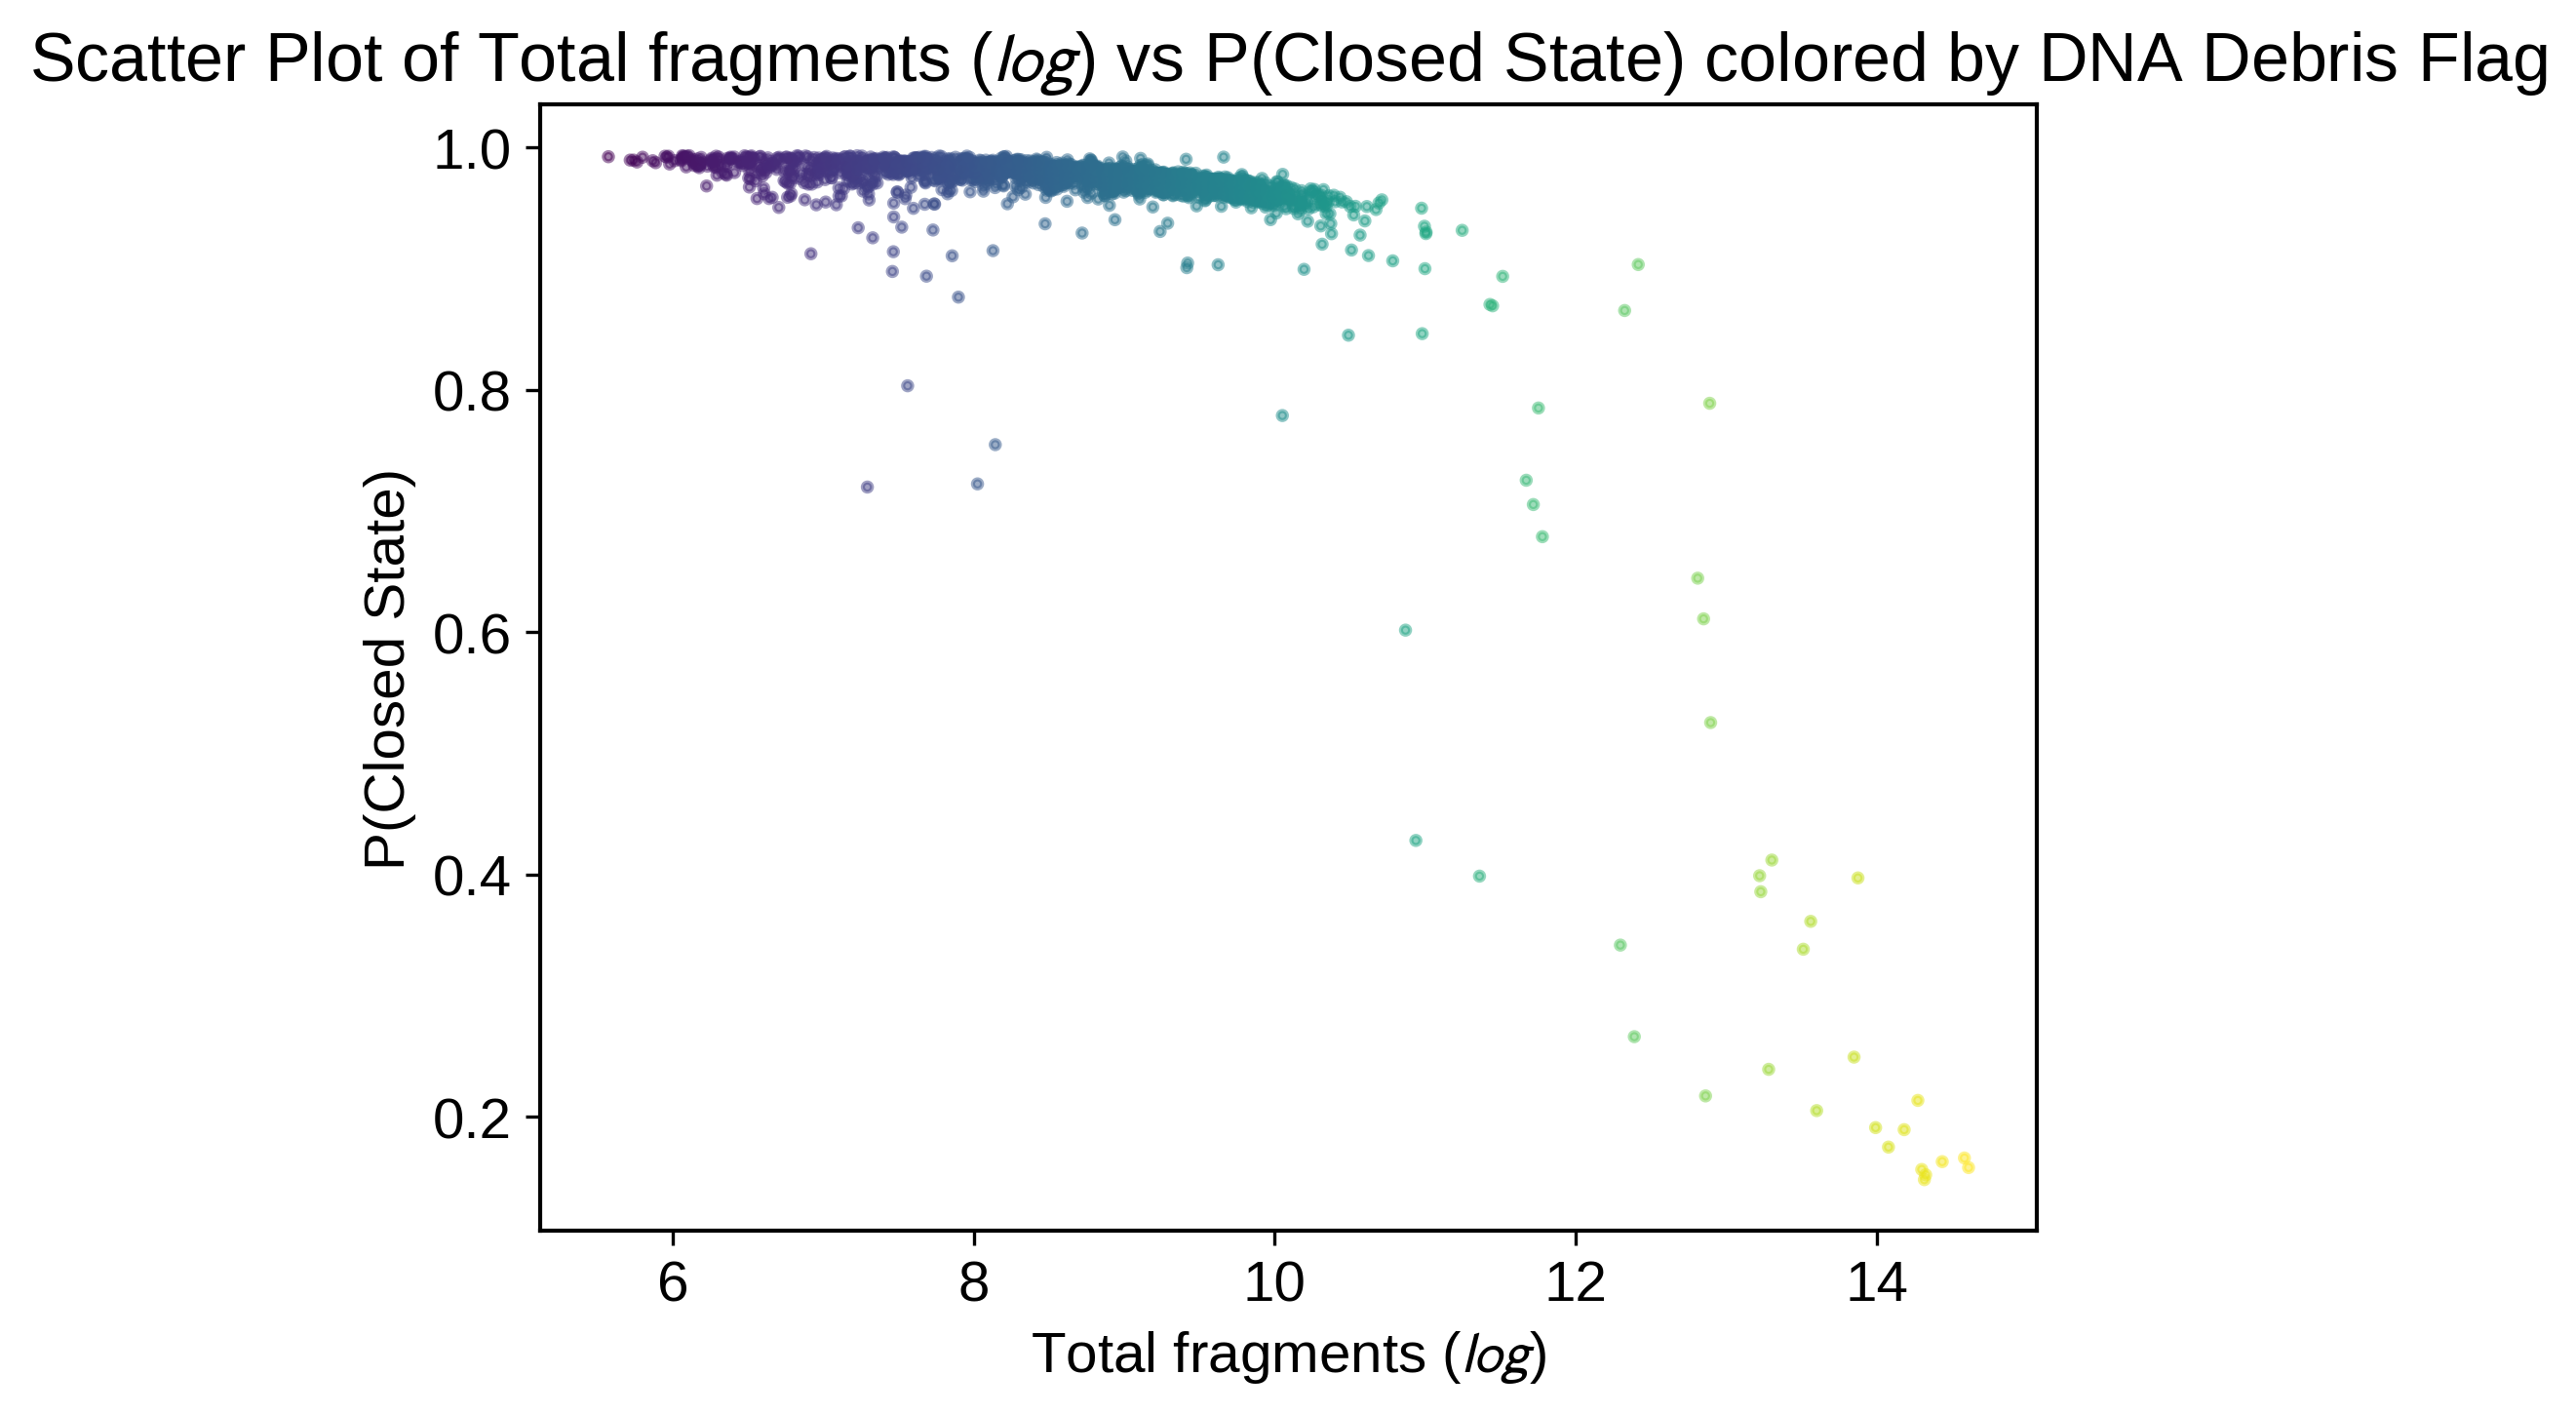

In [22]:
fig, ax = plt.subplots(figsize=(6.6, 5))
scatter2 = ax.scatter(entropy_w_DNAdebrisflag_df['log_total_fragments'], entropy_w_DNAdebrisflag_df['P_closed_state'], 
               c = entropy_w_DNAdebrisflag_df['log_total_fragments'],  alpha=0.5, s=5)


ax.set_xlabel('Total fragments ($log$)')
ax.set_ylabel('P(Closed State)')
ax.set_title('Scatter Plot of Total fragments ($log$) vs P(Closed State) colored by DNA Debris Flag')


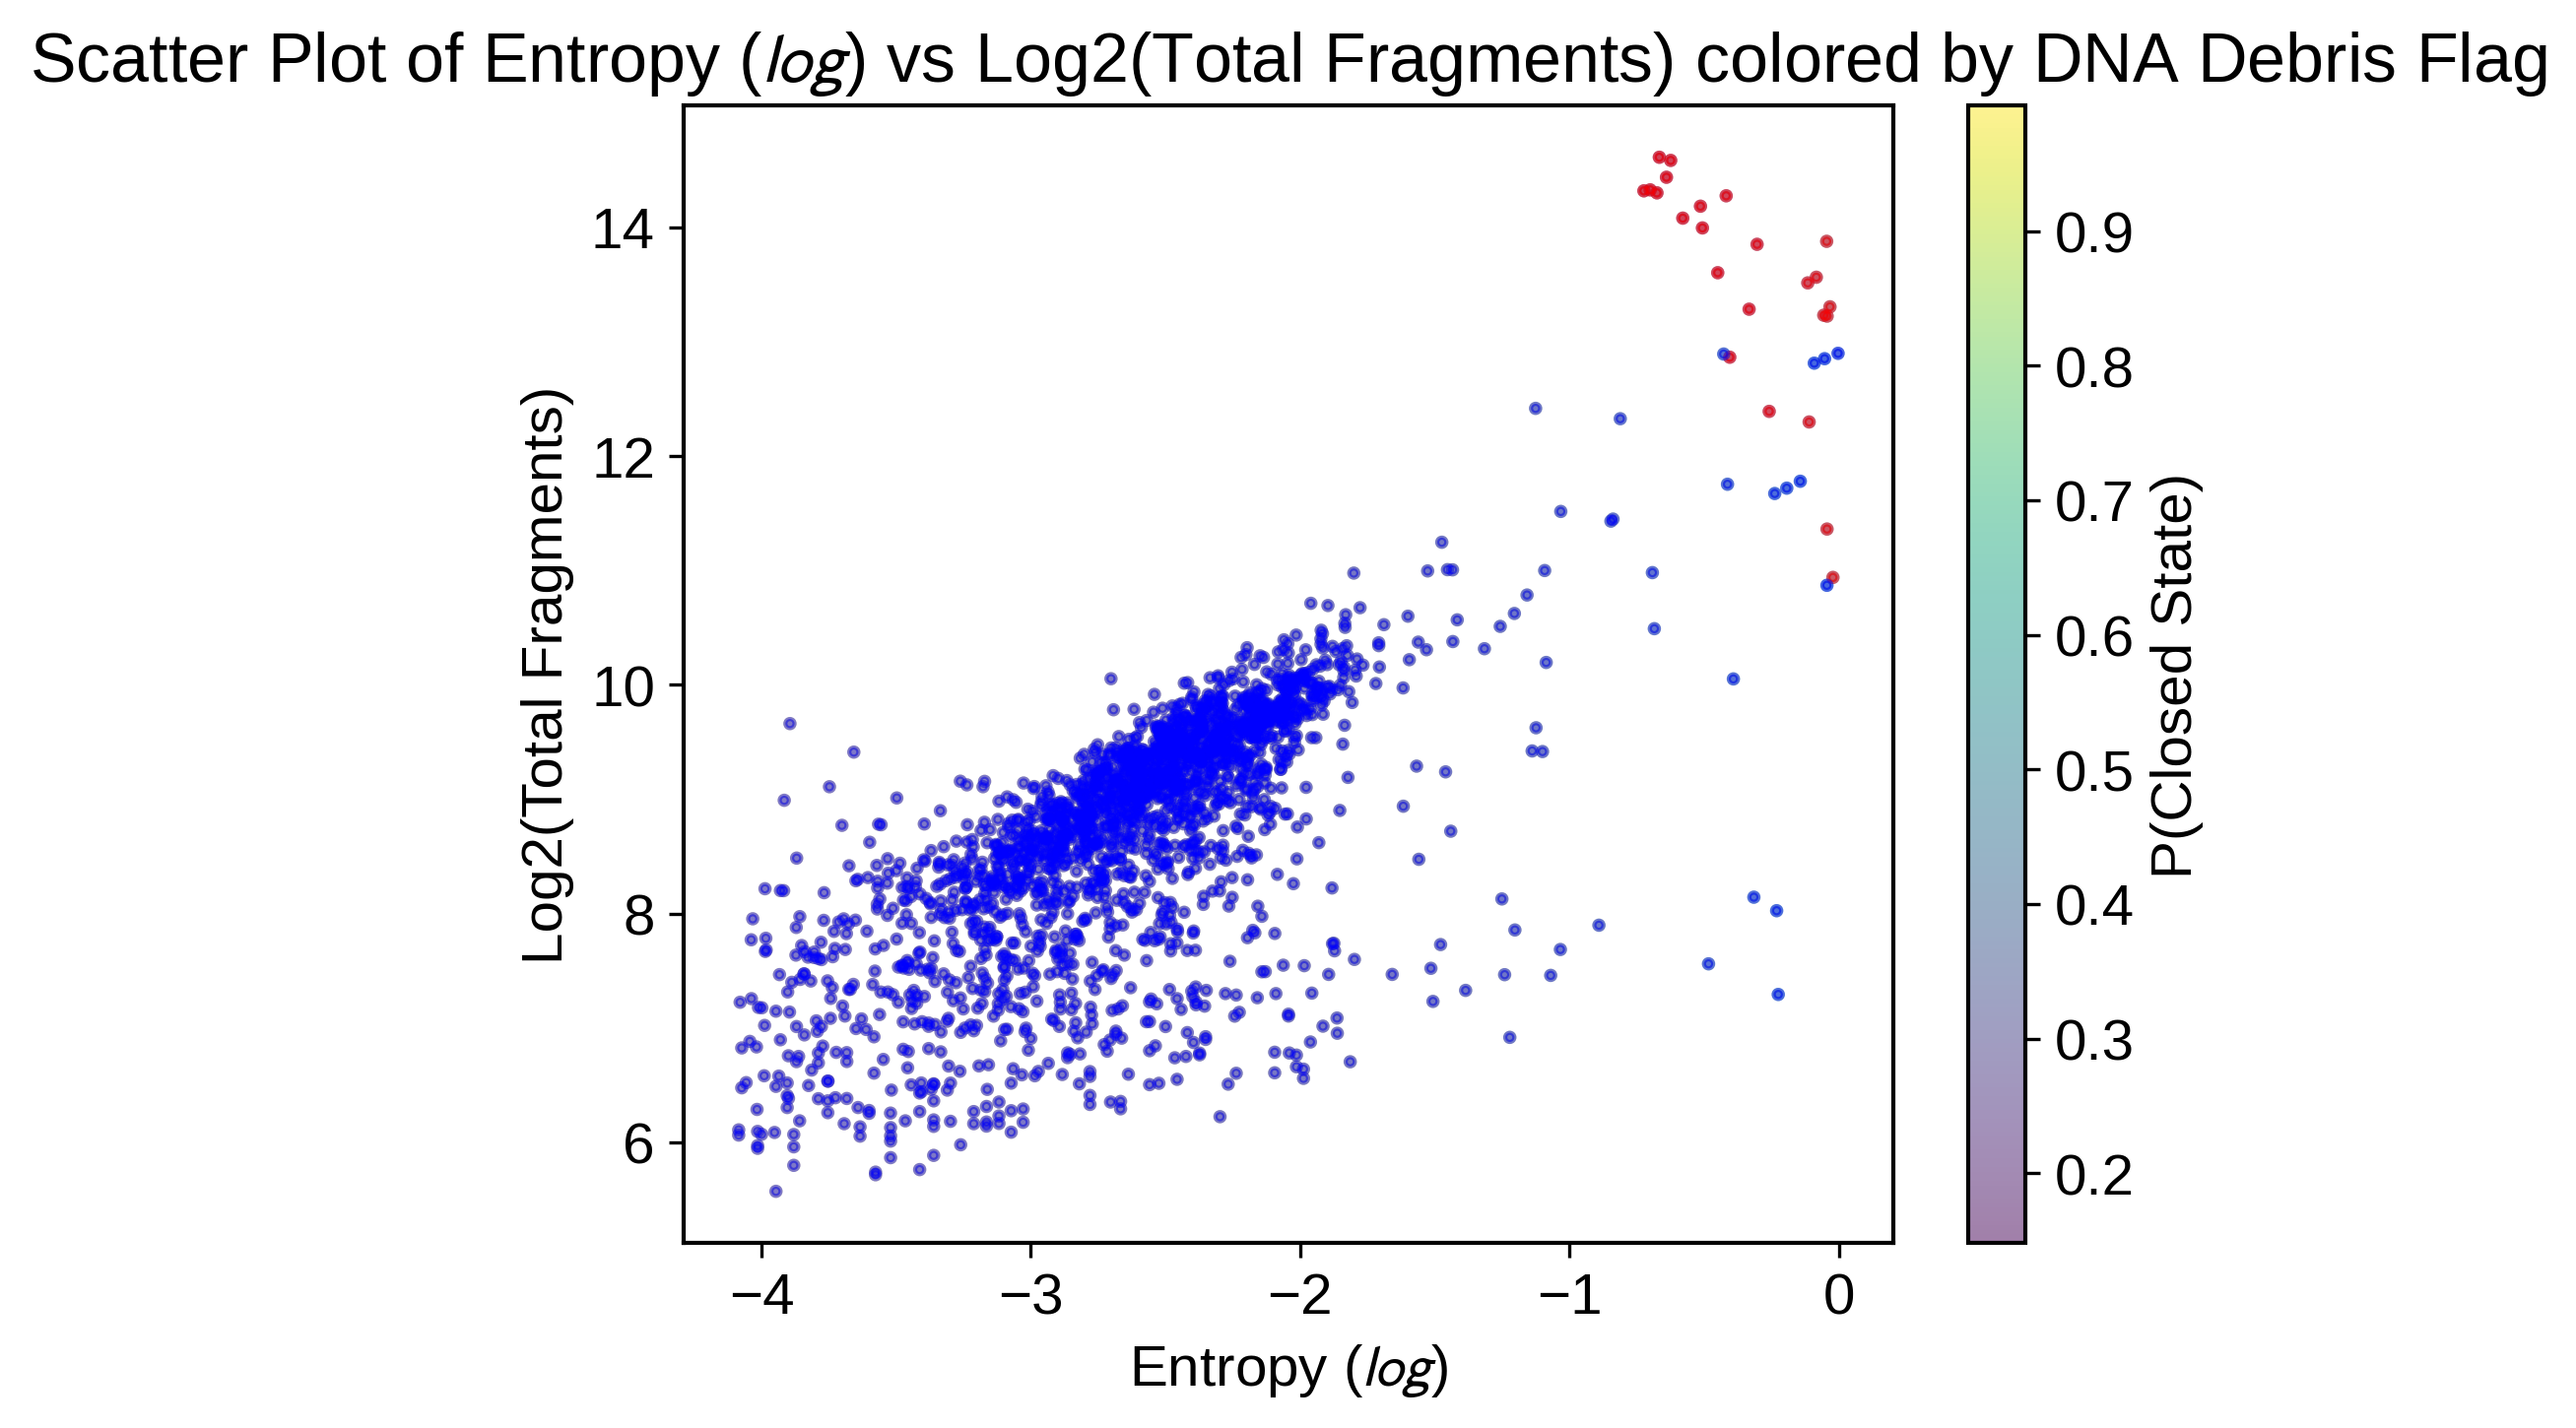

In [23]:
fig, ax = plt.subplots(figsize=(6.6, 5))
scatter2 = ax.scatter(entropy_w_DNAdebrisflag_df['log_entropy'], entropy_w_DNAdebrisflag_df['log_total_fragments'], 
               c = entropy_w_DNAdebrisflag_df['P_closed_state'],  alpha=0.5, s=5)
_ = ax.scatter(entropy_w_DNAdebrisflag_df['log_entropy'], entropy_w_DNAdebrisflag_df['log_total_fragments'], 
               c = entropy_w_DNAdebrisflag_df['DNA_debris'].map({'YES': 'red', 'NO': 'blue'}),  alpha=0.5, s=5)

ax.set_xlabel('Entropy ($log$)')
ax.set_ylabel('Log2(Total Fragments)')
ax.set_title('Scatter Plot of Entropy ($log$) vs Log2(Total Fragments) colored by DNA Debris Flag')

fig.colorbar(scatter2, label='P(Closed State)')

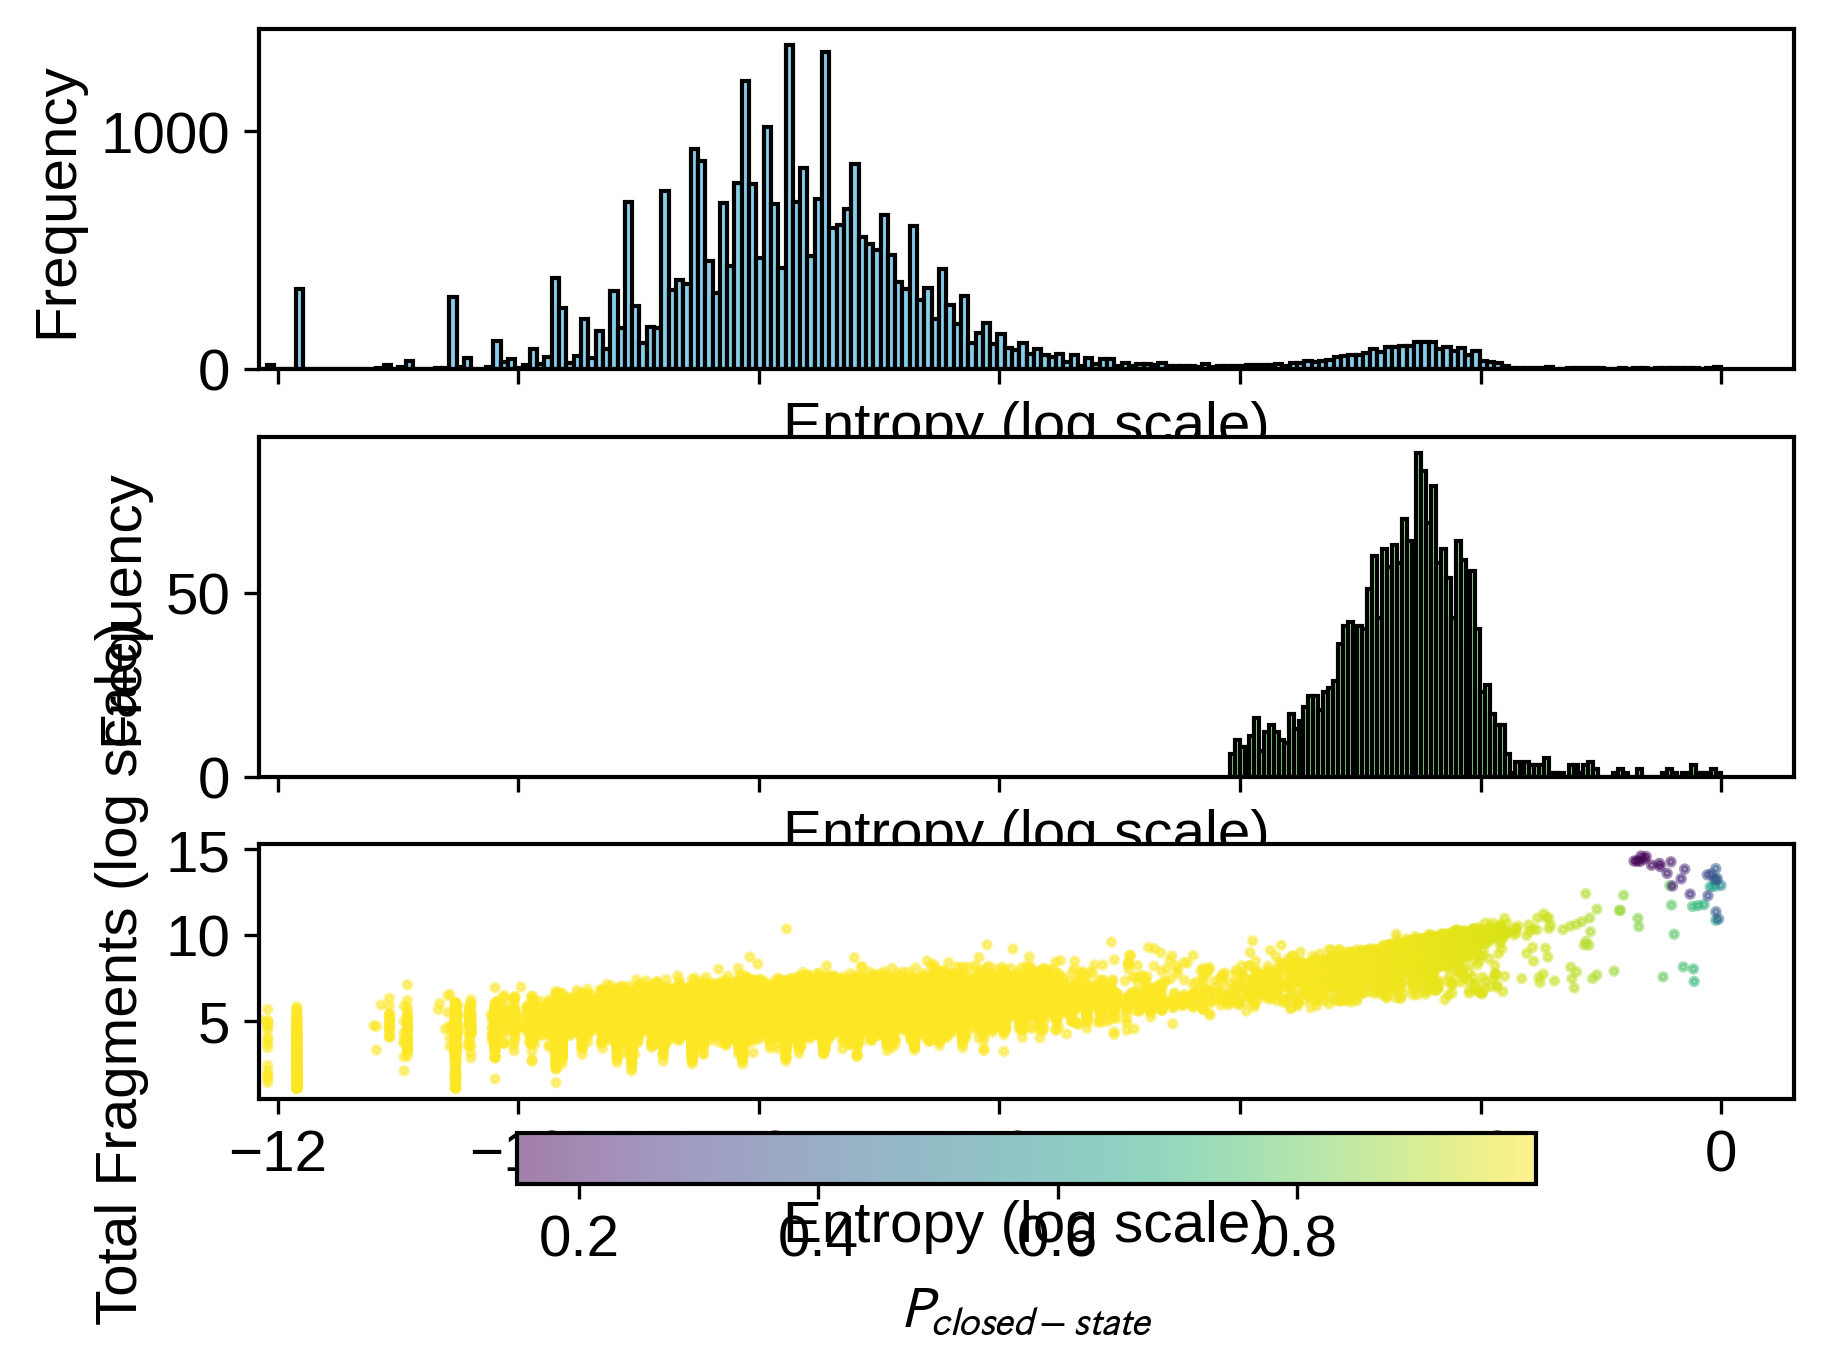

In [24]:
fig, ax = plt.subplots(figsize=(6.6, 5), nrows=3, ncols=1, sharex=True)
xlims = min(entropy_all['log_entropy'].min(), entropy_df['log_entropy'].min())

_ = ax[0].hist(entropy_all['log_entropy'], bins=200, color='skyblue', edgecolor='black')
_ = ax[1].hist(entropy_df['log_entropy'], bins=100, color='lightgreen', edgecolor='black')


ax[0].set_xlabel('Entropy (log scale)')
ax[0].set_ylabel('Frequency')

ax[1].set_xlabel('Entropy (log scale)')
ax[1].set_ylabel('Frequency')

ax[2].scatter(entropy_all['log_entropy'],
              entropy_all['log_total_fragments'],
                alpha=0.5, s= 3,
                c=entropy_all['P_closed_state'])
ax[2].set_xlabel('Entropy (log scale)')
ax[2].set_ylabel('Total Fragments (log scale)')
ax[2].set_xlim(xlims)
cbar = plt.colorbar(ax[2].collections[0], ax=ax[2],orientation="horizontal", pad=0.1,)
cbar.set_label('$P_{closed-state}$')



Text(0, 0.5, 'Frequency')

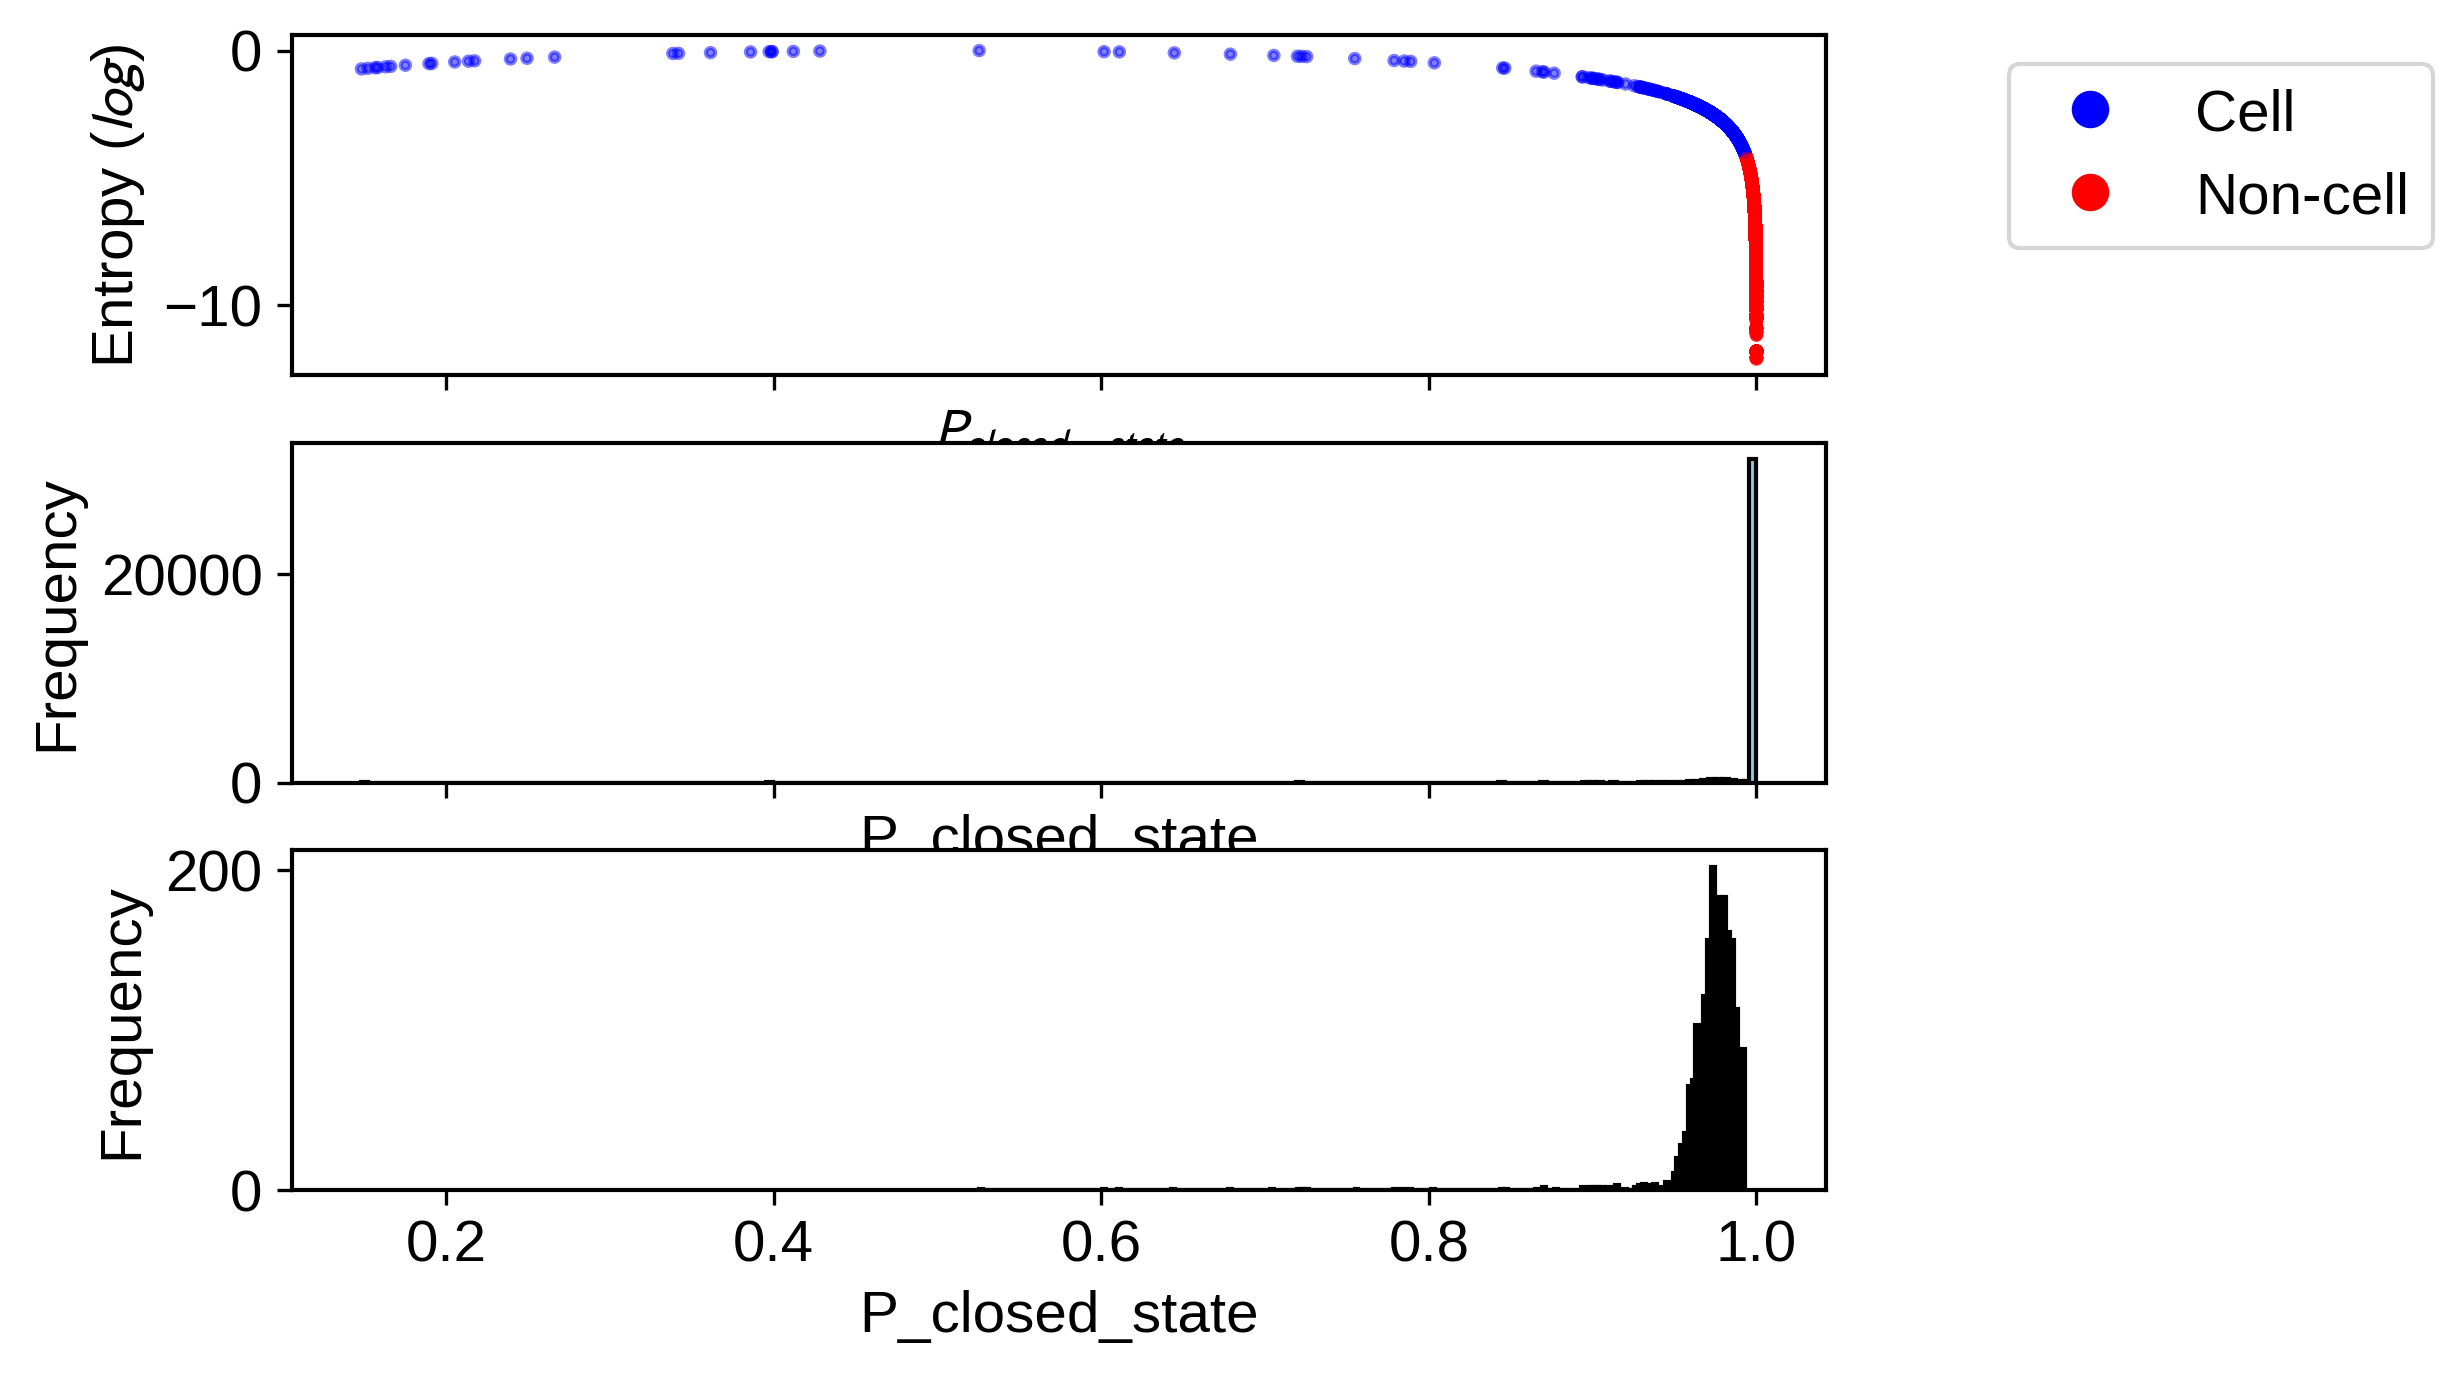

In [25]:
fig, ax = plt.subplots(nrows=3, figsize=(6.6, 5), sharex=True)
entropy_all['cell'] = entropy_all['log_entropy'] >= entropy_df['log_entropy'].min()
ax[0].scatter(entropy_all['P_closed_state'], entropy_all['log_entropy'],  alpha=0.5,
           c=entropy_all['cell'].map({True: 'blue', False: 'red'}), 
           s = 5)
ax[0].set_ylabel('Entropy ($log$)')
ax[0].set_xlabel('$P_{closed-state}$')
ax[0].legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Cell', markerfacecolor='blue', markersize=10),
                   plt.Line2D([0], [0], marker='o', color='w', label='Non-cell', markerfacecolor='red', markersize=10)], 
          bbox_to_anchor=(1.1, 1), loc='upper left')

_ = ax[1].hist(entropy_all['P_closed_state'], bins=200, color='skyblue', edgecolor='black')
ax[1].set_xlabel('P_closed_state')
ax[1].set_ylabel('Frequency')

_ = ax[2].hist(entropy_df['P_closed_state'], bins=200, color='skyblue', edgecolor='black')
ax[2].set_xlabel('P_closed_state')
ax[2].set_ylabel('Frequency')